In [2]:
#mount drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files

# Upload kaggle.json manually
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bidishacodes","key":"6c97821d28a6d9f7a512ca9c43850eb8"}'}

# Task 2A

In [4]:
import os
import zipfile

# Create the .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move the kaggle.json file into that directory
!mv kaggle.json /root/.kaggle/

# Change the permissions of the file
!chmod 600 /root/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d hbchaitanyabharadwaj/audio-dataset-with-10-indian-languages

Dataset URL: https://www.kaggle.com/datasets/hbchaitanyabharadwaj/audio-dataset-with-10-indian-languages
License(s): CC0-1.0


In [6]:
with zipfile.ZipFile('audio-dataset-with-10-indian-languages.zip', 'r') as zip_ref:
    zip_ref.extractall('indian_languages_audio')

In [9]:
# Check extracted files
!ls /content/indian_languages_audio/Language Detection Dataset


ls: cannot access '/content/indian_languages_audio/Language': No such file or directory
ls: cannot access 'Detection': No such file or directory
ls: cannot access 'Dataset': No such file or directory


In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/indian_languages_audio/Language Detection Dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/content/indian_languages_audio/Language Detection Dataset/Hindi/10153.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/8011.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/24688.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/5014.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/10607.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/3586.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/11580.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/23795.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/12406.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/7023.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/20643.mp3
/content/indian_languages_audio/Language Detection Dataset/Hindi/16511.mp3
/content/indian_languages_audio/Language Detection Da

In [11]:

!pip install torch torchaudio librosa matplotlib seaborn scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [12]:
import os

base_dir = '/content/indian_languages_audio'
input_dir = '/content/indian_languages_audio/Language Detection Dataset'
results_dir = f'{base_dir}/results'

os.makedirs(f'{results_dir}/features', exist_ok=True)
os.makedirs(f'{results_dir}/spectrograms', exist_ok=True)
os.makedirs(f'{results_dir}/stats', exist_ok=True)

print(f"Project directories created at {results_dir}")

Project directories created at /content/indian_languages_audio/results


In [13]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
import librosa
import librosa.display
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm  # Better for Jupyter notebooks
import json
import time
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [14]:
class MFCCExtractor:
    def __init__(self, n_mfcc=13, sample_rate=16000):
        self.n_mfcc = n_mfcc
        self.sample_rate = sample_rate
        # Use torchaudio transform for MFCC extraction
        self.mfcc_transform = torchaudio.transforms.MFCC(
            sample_rate=sample_rate,
            n_mfcc=n_mfcc,
            log_mels=True,
            melkwargs={"n_fft": 2048, "hop_length": 512, "n_mels": 128}
        )

    def extract_from_file(self, file_path):
        try:
            # First try using torchaudio (faster)
            try:
                waveform, sr = torchaudio.load(file_path)
                # Convert to mono if needed
                if waveform.shape[0] > 1:
                    waveform = torch.mean(waveform, dim=0, keepdim=True)

                # Resample if needed
                if sr != self.sample_rate:
                    resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                    waveform = resampler(waveform)
                    sr = self.sample_rate

                # Extract MFCCs
                mfccs = self.mfcc_transform(waveform)
                # Convert to numpy for consistency
                mfccs_np = mfccs.squeeze().numpy()

            # Fallback to librosa
            except:
                y, sr = librosa.load(file_path, sr=self.sample_rate)
                mfccs_np = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)

            # Get metadata
            file_name = os.path.basename(file_path)

            return {
                'file_path': file_path,
                'file_name': file_name,
                'mfccs': mfccs_np,
                'sample_rate': sr,
                'shape': mfccs_np.shape
            }
        except Exception as e:
            print(f"Error extracting MFCCs from {file_path}: {str(e)}")
            return None

    def extract_from_directory(self, directory, max_samples=None):
        """Extract MFCCs from all audio files in a directory."""
        # Get all audio files
        audio_files = [f for f in os.listdir(directory) if f.lower().endswith(('.wav', '.mp3'))]

        # Sample if max_samples is specified
        if max_samples and len(audio_files) > max_samples:
            audio_files = random.sample(audio_files, max_samples)

        # Process each file
        results = []
        for audio_file in tqdm(audio_files, desc=f"Processing {os.path.basename(directory)}"):
            file_path = os.path.join(directory, audio_file)
            result = self.extract_from_file(file_path)
            if result:
                results.append(result)

        return results

    def save_features_batch(self, features_list, output_dir, language=None):
        """Save a batch of MFCC features to JSON files."""
        if language:
            output_dir = os.path.join(output_dir, language)

        os.makedirs(output_dir, exist_ok=True)
        saved_files = []

        for features in features_list:
            # Create a serializable copy and save
            serializable = {k: v.tolist() if isinstance(v, np.ndarray) else v
                           for k, v in features.items()}

            file_name = f"{os.path.splitext(features['file_name'])[0]}.json"
            output_file = os.path.join(output_dir, file_name)

            try:
                with open(output_file, 'w') as f:
                    json.dump(serializable, f)
                saved_files.append(output_file)
            except Exception as e:
                print(f"Error saving features to {output_file}: {str(e)}")

        return saved_files

In [15]:
def process_language(language, data_dir, output_dir, n_mfcc=13, max_samples=None):

    # Find the language directory
    language_dir = None
    for root, dirs, files in os.walk(data_dir):
        if os.path.basename(root) == language:
            language_dir = root
            break

    if not language_dir:
        print(f"Language directory not found for: {language}")
        return []

    # Set up paths and create output directory
    features_dir = os.path.join(output_dir, 'features', language)
    os.makedirs(features_dir, exist_ok=True)

    # Create extractor and process files
    extractor = MFCCExtractor(n_mfcc=n_mfcc)
    features_list = extractor.extract_from_directory(language_dir, max_samples)

    # Save features
    saved_files = extractor.save_features_batch(features_list, features_dir)
    print(f"Processed {len(saved_files)} files for {language}")

    return saved_files

In [16]:
class MFCCVisualizer:

    def __init__(self, output_dir='results/spectrograms'):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
        # Set a consistent style for all plots
        sns.set_style("whitegrid")
        plt.rcParams.update({'font.size': 12})

    def load_features(self, feature_file):
        try:
            with open(feature_file, 'r') as f:
                data = json.load(f)
            # Convert lists back to numpy arrays
            data['mfccs'] = np.array(data['mfccs'])
            return data
        except Exception as e:
            print(f"Error loading features from {feature_file}: {str(e)}")
            return None

    def plot_spectrogram(self, mfccs, title=None, file_path=None):
        """Plot MFCC spectrogram with improved styling."""
        plt.figure(figsize=(10, 4))
        img = librosa.display.specshow(
            mfccs,
            x_axis='time',
            y_axis='mel',
            cmap='viridis'
        )
        plt.colorbar(img, format='%+2.0f dB')
        if title:
            plt.title(title)
        plt.tight_layout()

        if file_path:
            plt.savefig(file_path, dpi=300, bbox_inches='tight')

        return plt.gcf()

    def visualize_language(self, features_dir, language, num_samples=3):
        """Visualize MFCC features for a specific language."""
        # Set up paths
        language_features_dir = os.path.join(features_dir, language)
        language_output_dir = os.path.join(self.output_dir, language)
        os.makedirs(language_output_dir, exist_ok=True)

        # Check if directory exists
        if not os.path.exists(language_features_dir):
            print(f"Features directory not found: {language_features_dir}")
            return None

        # Load feature files
        feature_files = [os.path.join(language_features_dir, f)
                        for f in os.listdir(language_features_dir)
                        if f.endswith('.json')]

        if not feature_files:
            print(f"No feature files found for {language}")
            return None


        if len(feature_files) > num_samples:
            sample_files = random.sample(feature_files, num_samples)
        else:
            sample_files = feature_files

        #spectrograms
        spectrograms = []
        for i, file_path in enumerate(sample_files):
            features = self.load_features(file_path)
            if features:
                output_file = os.path.join(language_output_dir, f"{language}_sample_{i+1}.png")
                self.plot_spectrogram(features['mfccs'], f"{language} - Sample {i+1}", output_file)
                spectrograms.append(output_file)
                plt.close()

        # we'll first calculate the mean along time axis for each MFCC, then average those
        mfcc_means = []

        for file in feature_files:
            features = self.load_features(file)
            if features and 'mfccs' in features:
                # Average across time dimension (axis=1)
                mfcc_means.append(np.mean(features['mfccs'], axis=1))

        if mfcc_means:
            # Now we can safely calculate the mean across samples
            mean_coeffs = np.mean(np.array(mfcc_means), axis=0)

            # For visualization, create a "fake" spectrogram with these mean values
            # Repeat the mean value across multiple time steps
            time_steps = 100  # Arbitrary number of time steps for visualization
            mean_mfcc_viz = np.tile(mean_coeffs.reshape(-1, 1), (1, time_steps))

            mean_file = os.path.join(language_output_dir, f"{language}_mean.png")
            self.plot_spectrogram(mean_mfcc_viz, f"Mean MFCC - {language}", mean_file)
            plt.close()

            return {
                'language': language,
                'sample_spectrograms': spectrograms,
                'mean_spectrogram': mean_file,
                'mfcc_means': np.array(mfcc_means)  # Store coefficient means instead of full MFCCs
            }

        return None

    def visualize_comparison(self, language_data):
        comparison_dir = os.path.join(self.output_dir, 'comparison')
        os.makedirs(comparison_dir, exist_ok=True)

        # Extract MFCC mean data
        mfccs_dict = {}
        for data in language_data:
            if data:
                # Check if we have 'mfcc_means' (new format) or 'mfccs' (old format)
                if 'mfcc_means' in data:
                    mfccs_dict[data['language']] = data['mfcc_means']
                elif 'mfccs' in data:
                    # Backward compatibility: calculate means from full MFCCs
                    # (this might raise an error if shapes differ, but we're handling it in visualize_language)
                    try:
                        means = np.array([np.mean(mfcc, axis=1) for mfcc in data['mfccs']])
                        mfccs_dict[data['language']] = means
                    except Exception as e:
                        print(f"Error calculating means for {data['language']}: {e}")

        if len(mfccs_dict) < 2:
            print("Need at least two languages for comparison")
            return None

        # Create coefficient comparison plot
        plt.figure(figsize=(12, 6))
        for language, means in mfccs_dict.items():
            # Calculate mean across samples
            mean_coeffs = np.mean(means, axis=0)
            plt.plot(range(1, len(mean_coeffs) + 1), mean_coeffs, marker='o', linewidth=2, label=language)

        plt.xlabel('MFCC Coefficient')
        plt.ylabel('Mean Value')
        plt.title('Comparison of Mean MFCC Coefficients Across Languages')
        plt.xticks(range(1, len(mean_coeffs) + 1))
        plt.legend()
        plt.grid(True)

        coeff_file = os.path.join(comparison_dir, 'coefficient_comparison.png')
        plt.savefig(coeff_file, dpi=300, bbox_inches='tight')
        plt.close()

        # Create heatmap
        data = {}
        for language, means in mfccs_dict.items():
            data[language] = np.mean(means, axis=0)

        df = pd.DataFrame(data).T
        df.columns = [f'MFCC_{i+1}' for i in range(df.shape[1])]

        plt.figure(figsize=(12, 6))
        sns.heatmap(df, annot=True, cmap='viridis', fmt='.2f')
        plt.title('Heatmap of Mean MFCC Coefficients Across Languages')

        heatmap_file = os.path.join(comparison_dir, 'mfcc_heatmap.png')
        plt.savefig(heatmap_file, dpi=300, bbox_inches='tight')
        plt.close()

        return {
            'coefficient_comparison': coeff_file,
            'heatmap': heatmap_file
        }

In [18]:
# Main workflow execution
# Define parameters
selected_languages = ['Bengali', 'Malayalam', 'Hindi']
n_mfcc = 13
max_samples = 2000

# Locate audio files
print("=== Locating audio files ===")
language_dirs = {}
for language in selected_languages:
    for root, _, _ in os.walk(input_dir):
        if os.path.basename(root) == language:
            language_dirs[language] = root
            print(f"Found {language} directory: {root}")
            break

if set(language_dirs.keys()) != set(selected_languages):
    missing = set(selected_languages) - set(language_dirs.keys())
    print(f"Warning: Could not find directories for: {missing}")
    # Continue with found languages
    selected_languages = list(language_dirs.keys())

# Extract MFCCs for each language
print("\n=== Extracting MFCC features ===")
for language in tqdm(selected_languages, desc="Processing languages"):
    print(f"\nProcessing {language}...")
    process_language(language, input_dir, results_dir, n_mfcc, max_samples)

# Visualize MFCCs
print("\n=== Visualizing MFCC features ===")
visualizer = MFCCVisualizer(output_dir=f"{results_dir}/spectrograms")
language_data = []

# Process each language
for language in tqdm(selected_languages, desc="Visualizing languages"):
    print(f"\nVisualizing {language}...")
    lang_data = visualizer.visualize_language(
        f"{results_dir}/features",
        language,
        num_samples=3
    )
    if lang_data:
        language_data.append(lang_data)

# Create comparison visualizations
if len(language_data) > 1:
    print("\nCreating comparison visualizations...")
    visualizer.visualize_comparison(language_data)
    print("Comparison visualizations created successfully")

print("\n=== MFCC extraction and visualization complete ===")

=== Locating audio files ===
Found Bengali directory: /content/indian_languages_audio/Language Detection Dataset/Bengali
Found Malayalam directory: /content/indian_languages_audio/Language Detection Dataset/Malayalam
Found Hindi directory: /content/indian_languages_audio/Language Detection Dataset/Hindi

=== Extracting MFCC features ===


Processing languages:   0%|          | 0/3 [00:00<?, ?it/s]


Processing Bengali...


Processing Bengali:   0%|          | 0/2000 [00:00<?, ?it/s]

Processed 2000 files for Bengali

Processing Malayalam...


...

Processed 2000 files for Malayalam

Processing Hindi...


Processing Hindi:   0%|          | 0/2000 [00:00<?, ?it/s]

Processed 2000 files for Hindi

=== Visualizing MFCC features ===


Visualizing languages:   0%|          | 0/3 [00:00<?, ?it/s]


Visualizing Bengali...

Visualizing Malayalam...

Visualizing Hindi...

Creating comparison visualizations...
Comparison visualizations created successfully

=== MFCC extraction and visualization complete ===


Sample MFCC Spectrograms:


### Bengali Sample MFCC Spectrogram

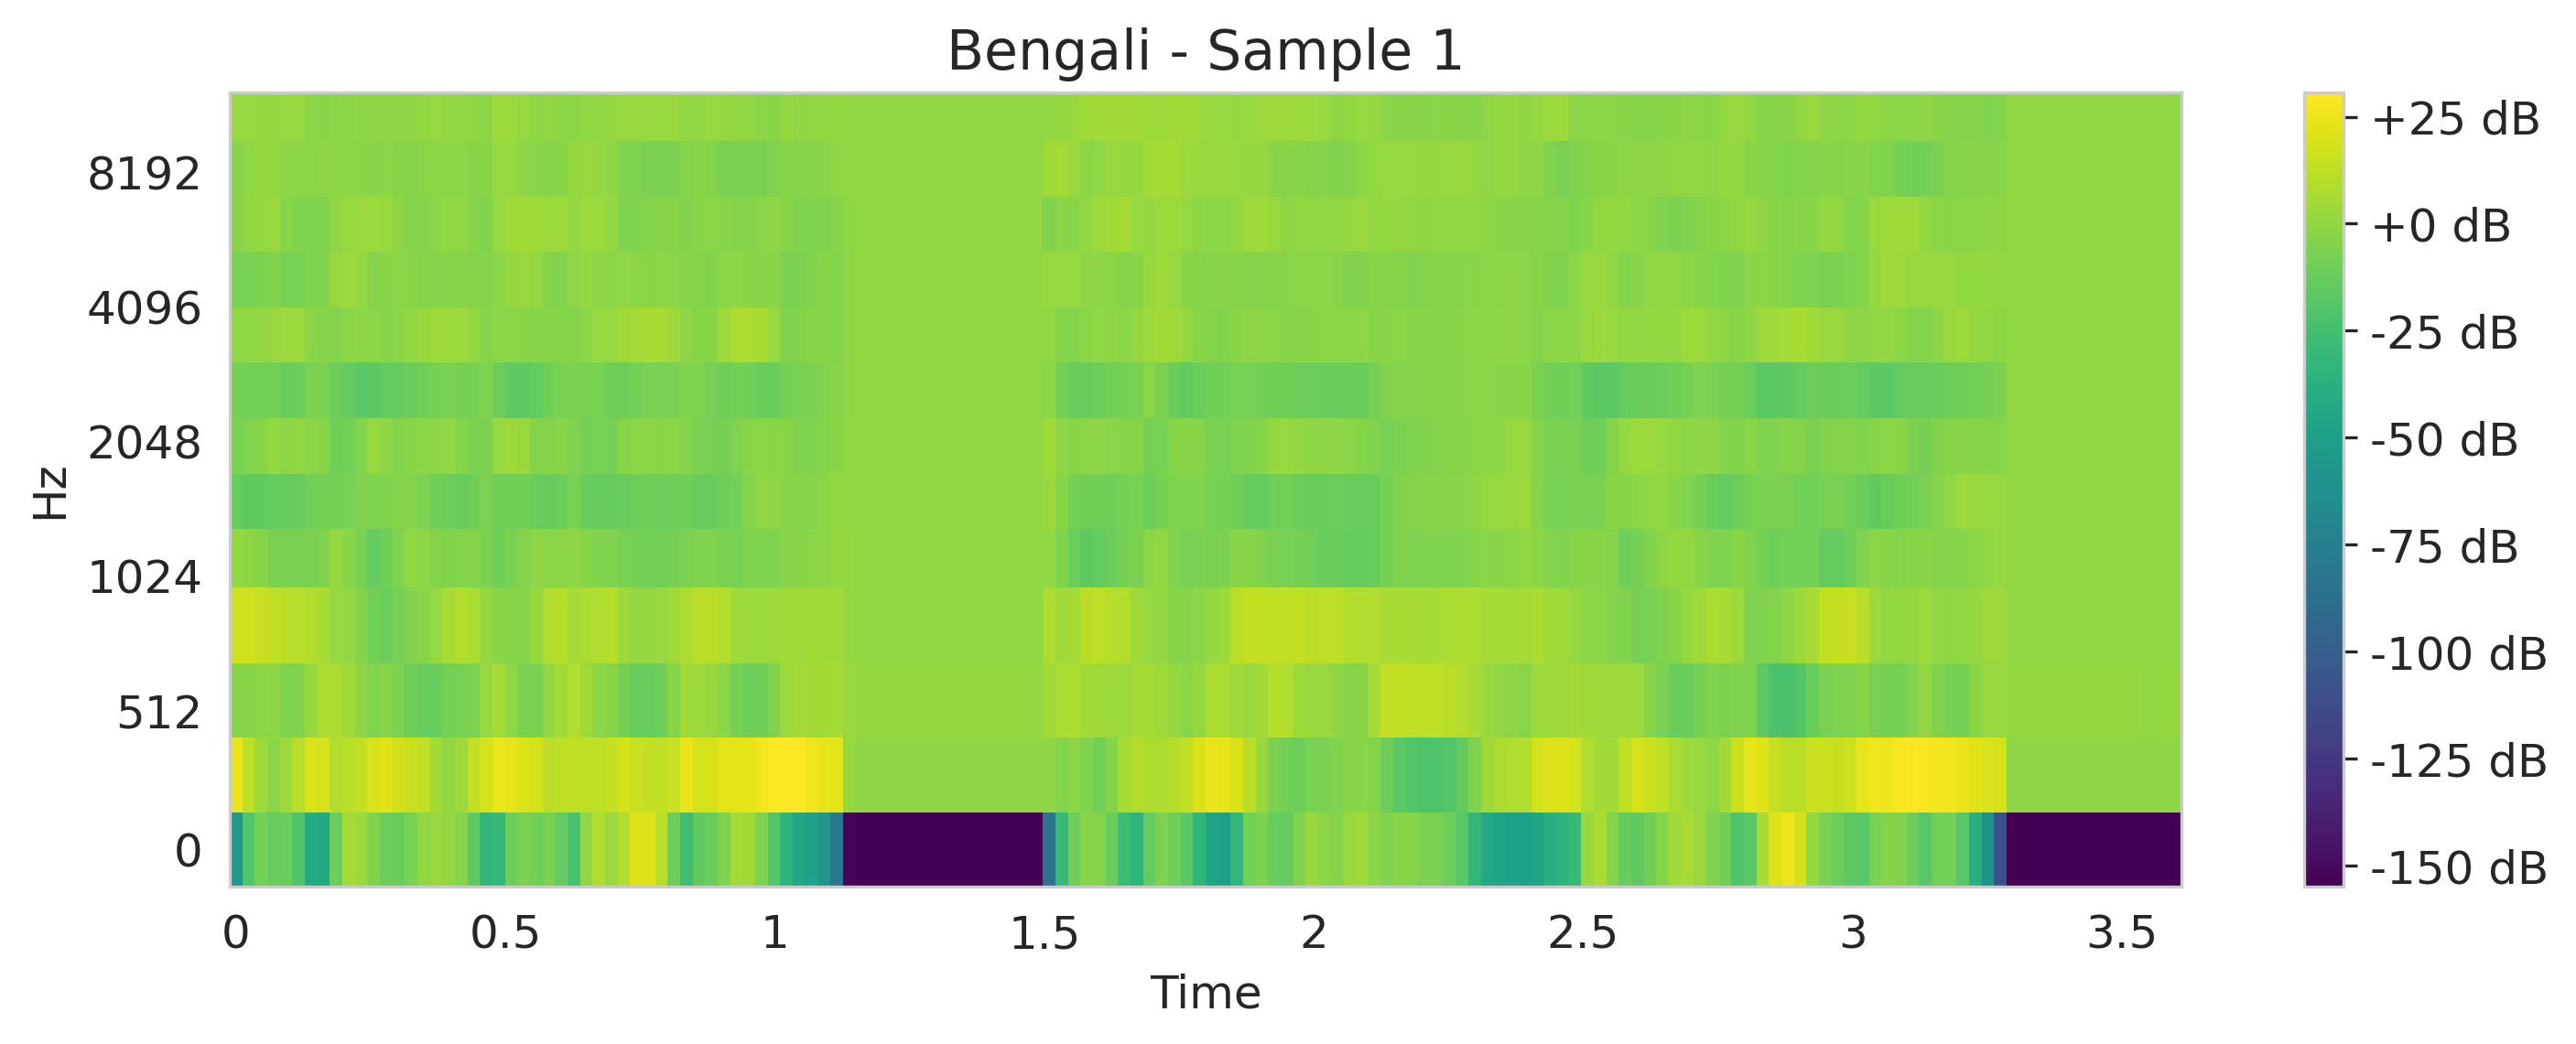

### Malayalam Sample MFCC Spectrogram

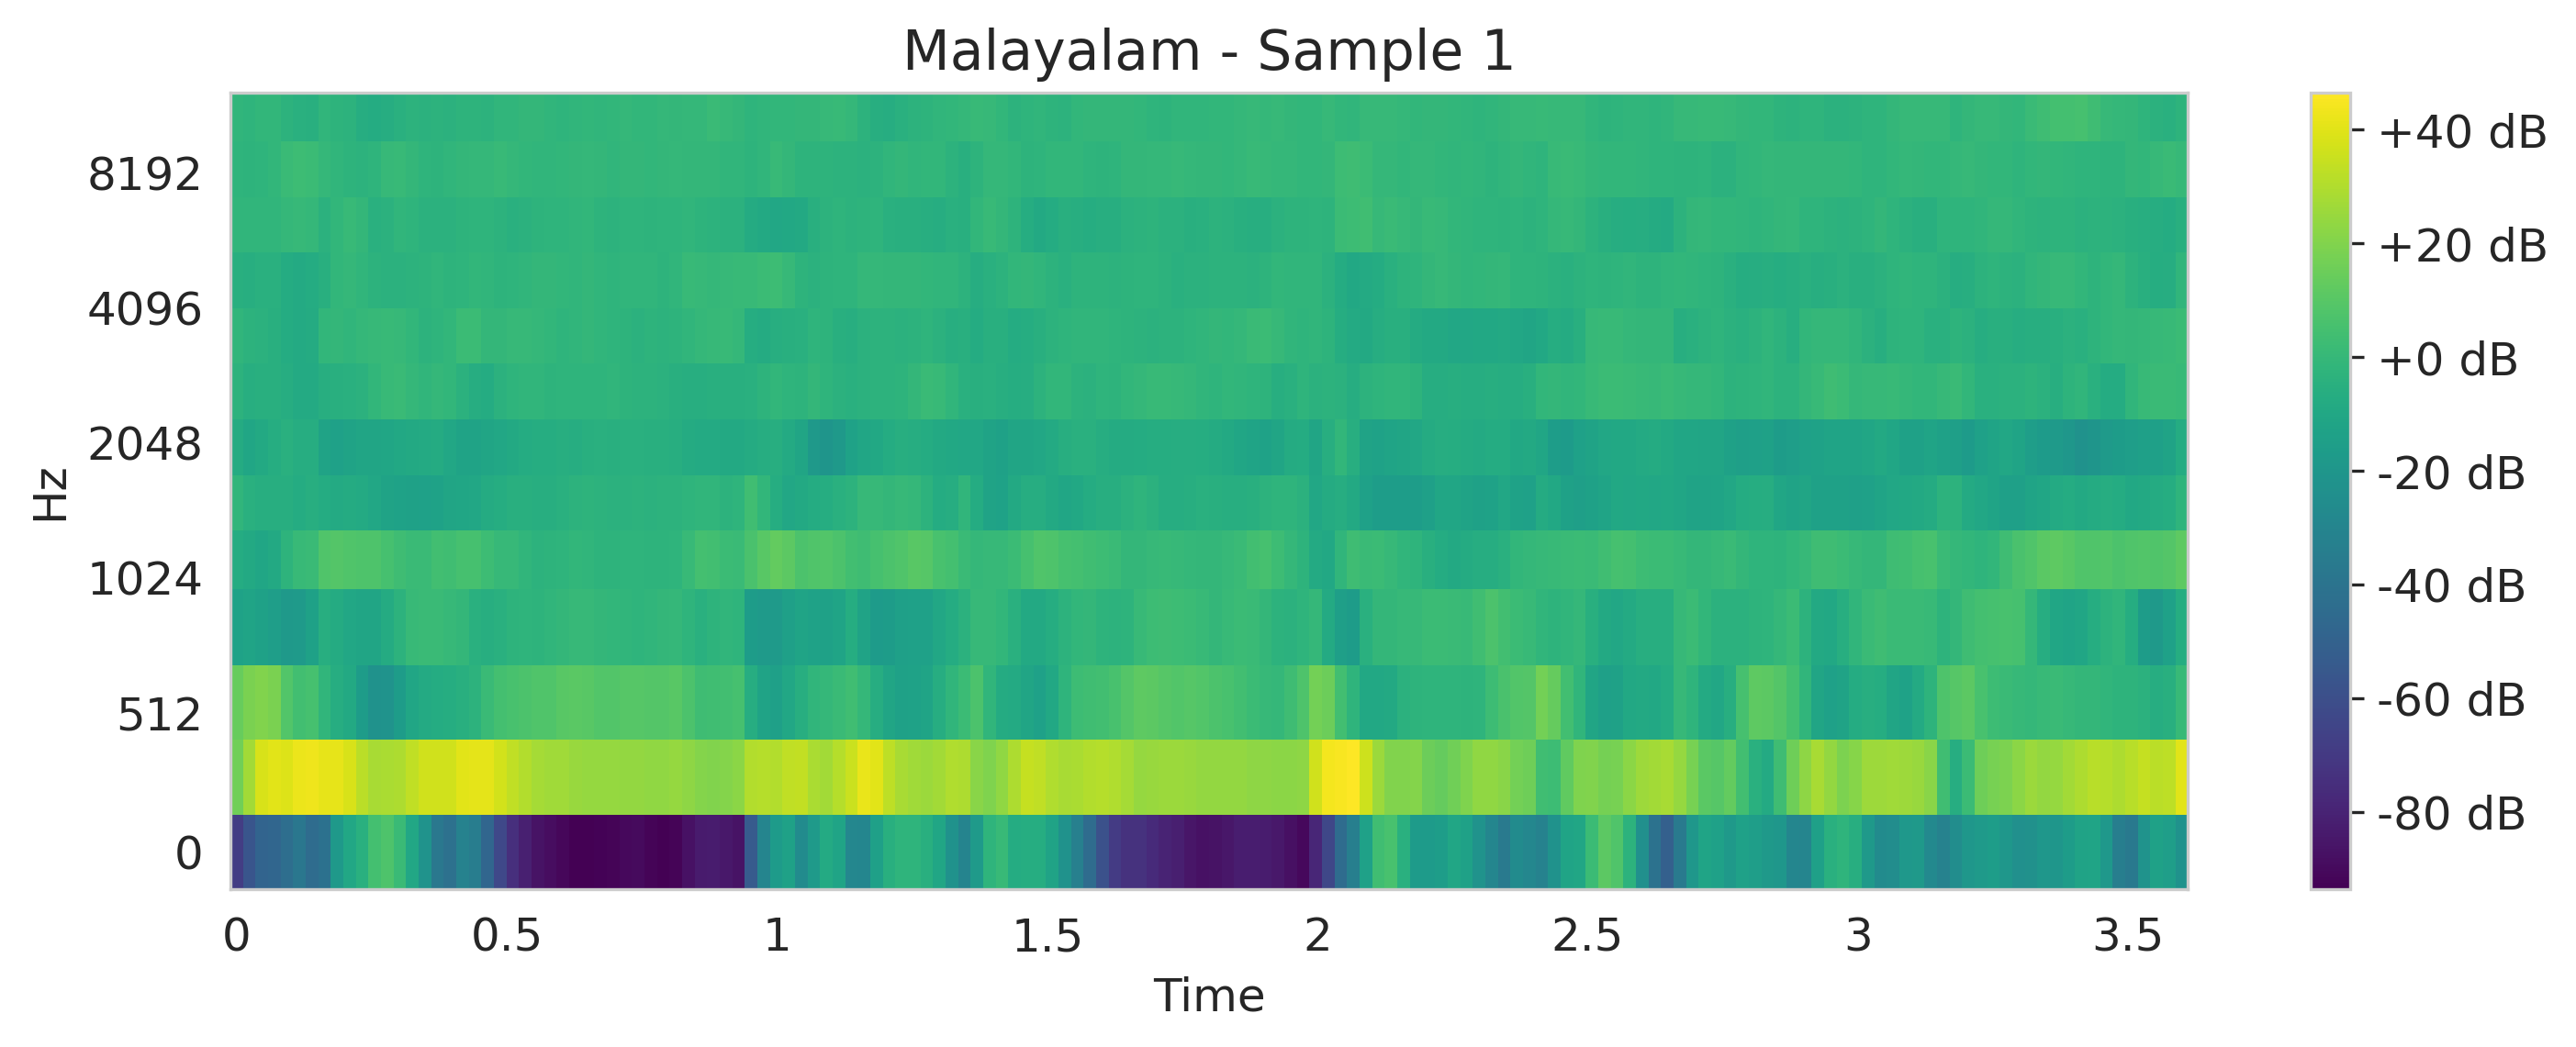

### Hindi Sample MFCC Spectrogram

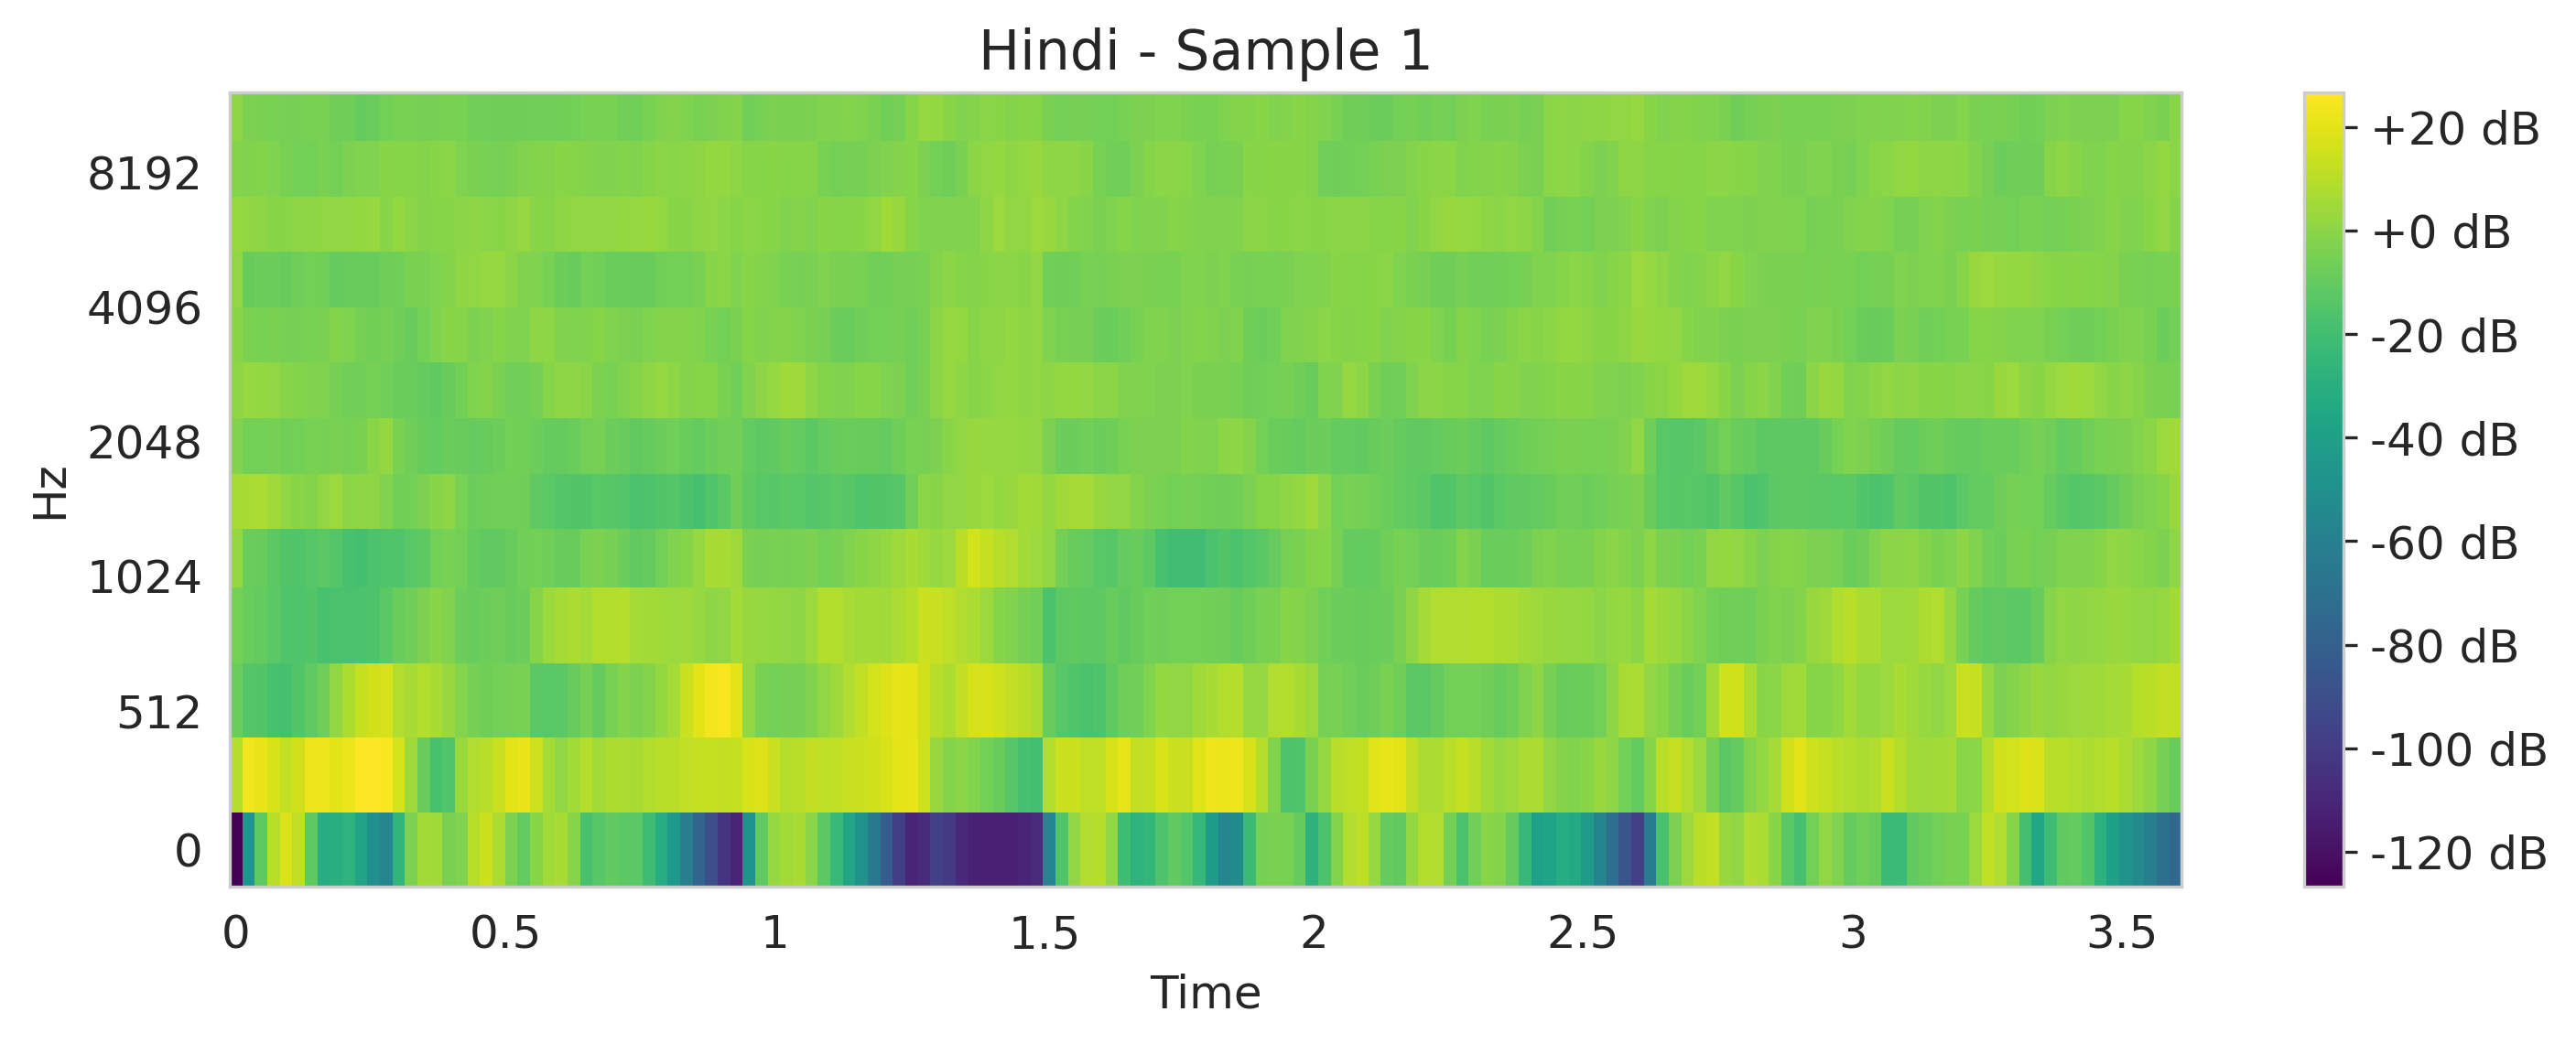


Mean MFCC Spectrograms:


### Mean MFCC - Bengali

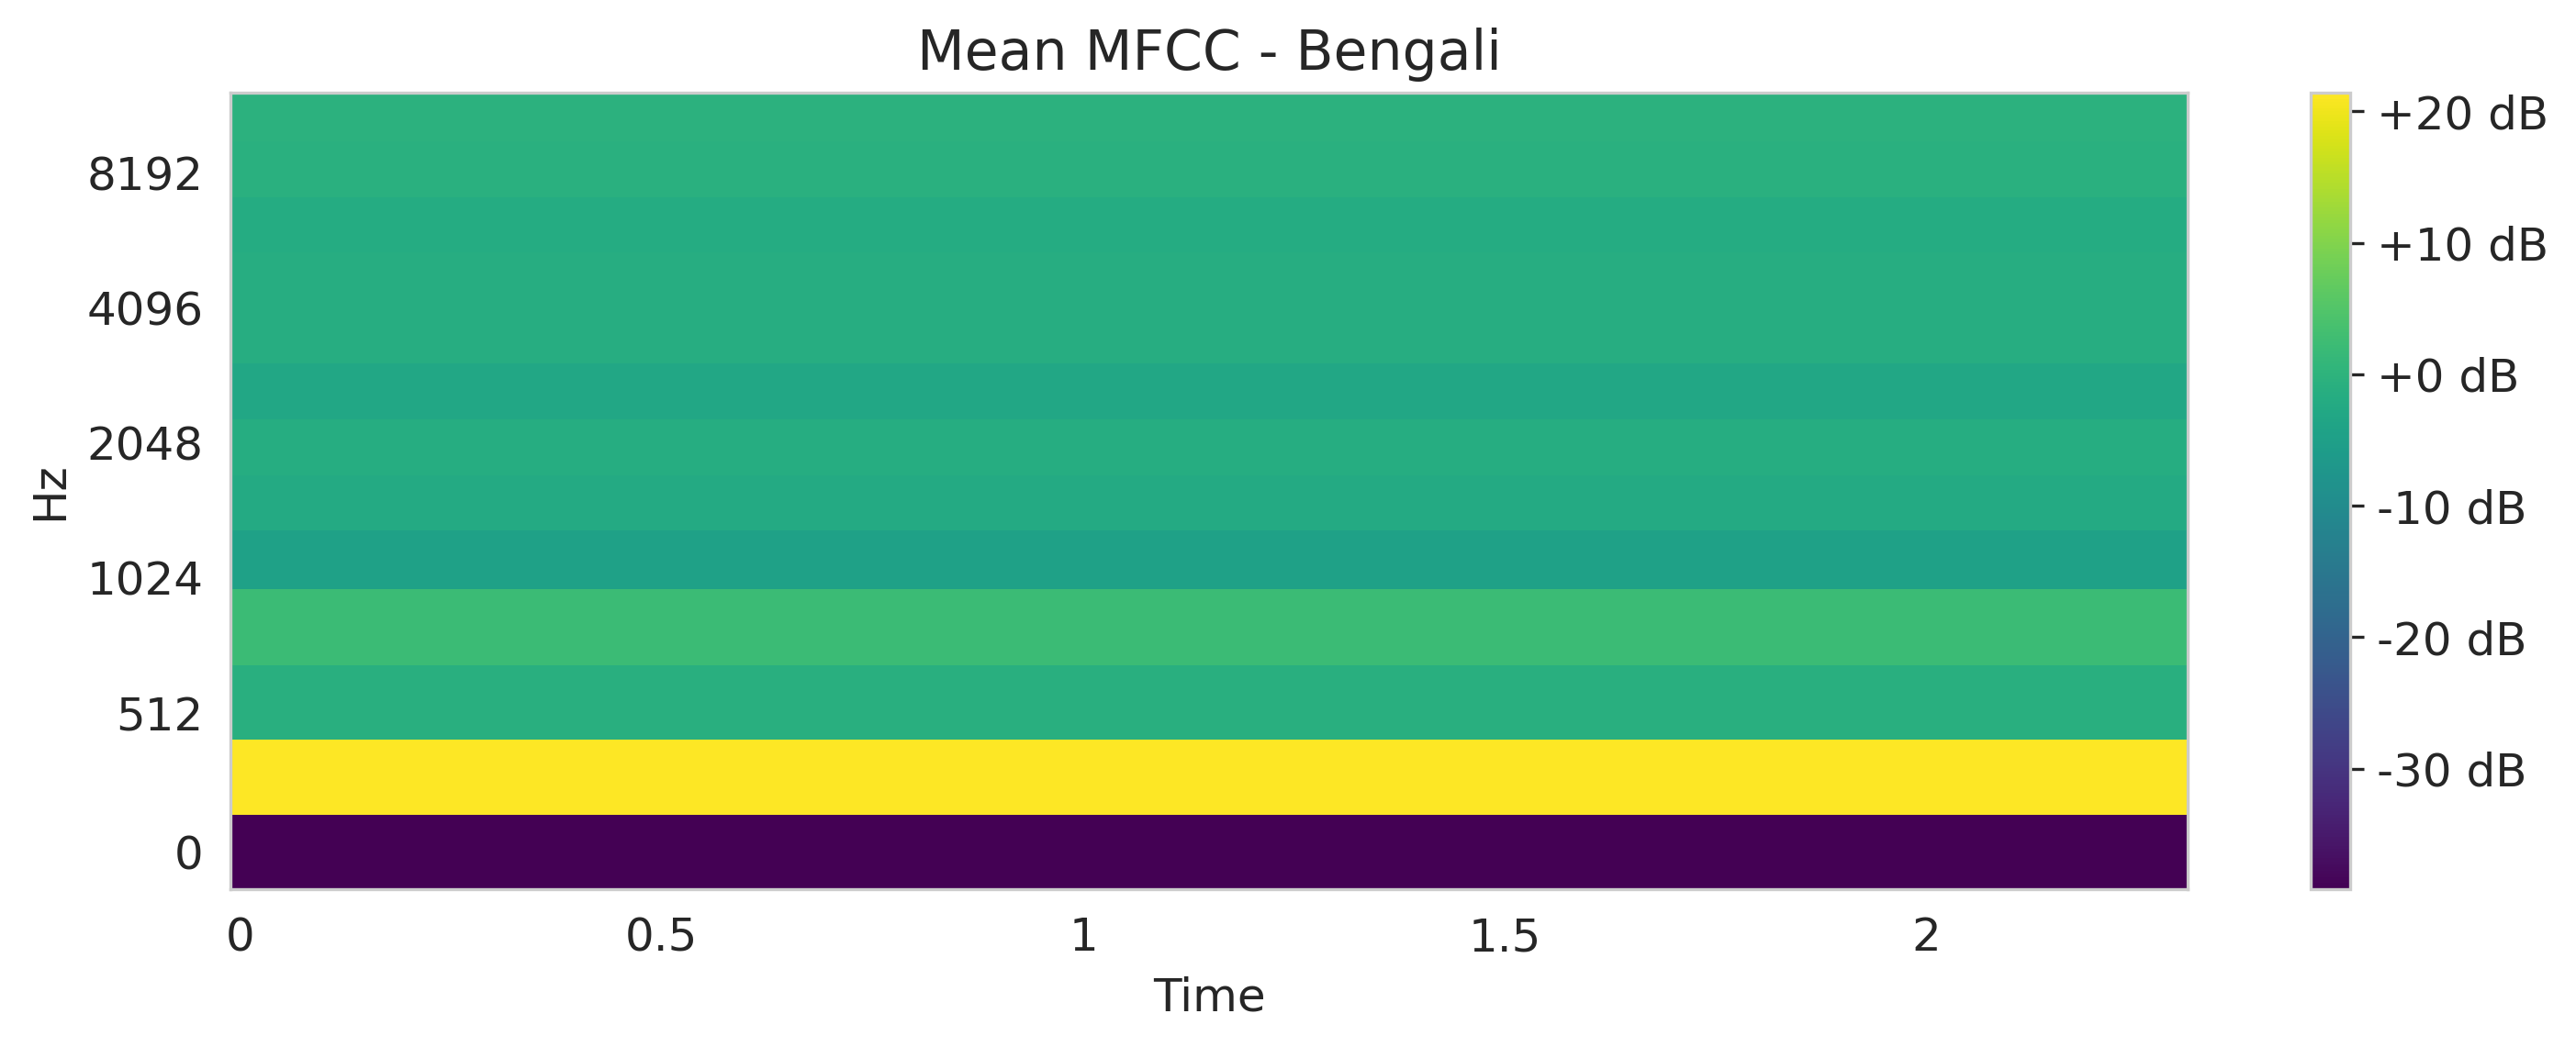

### Mean MFCC - Malayalam

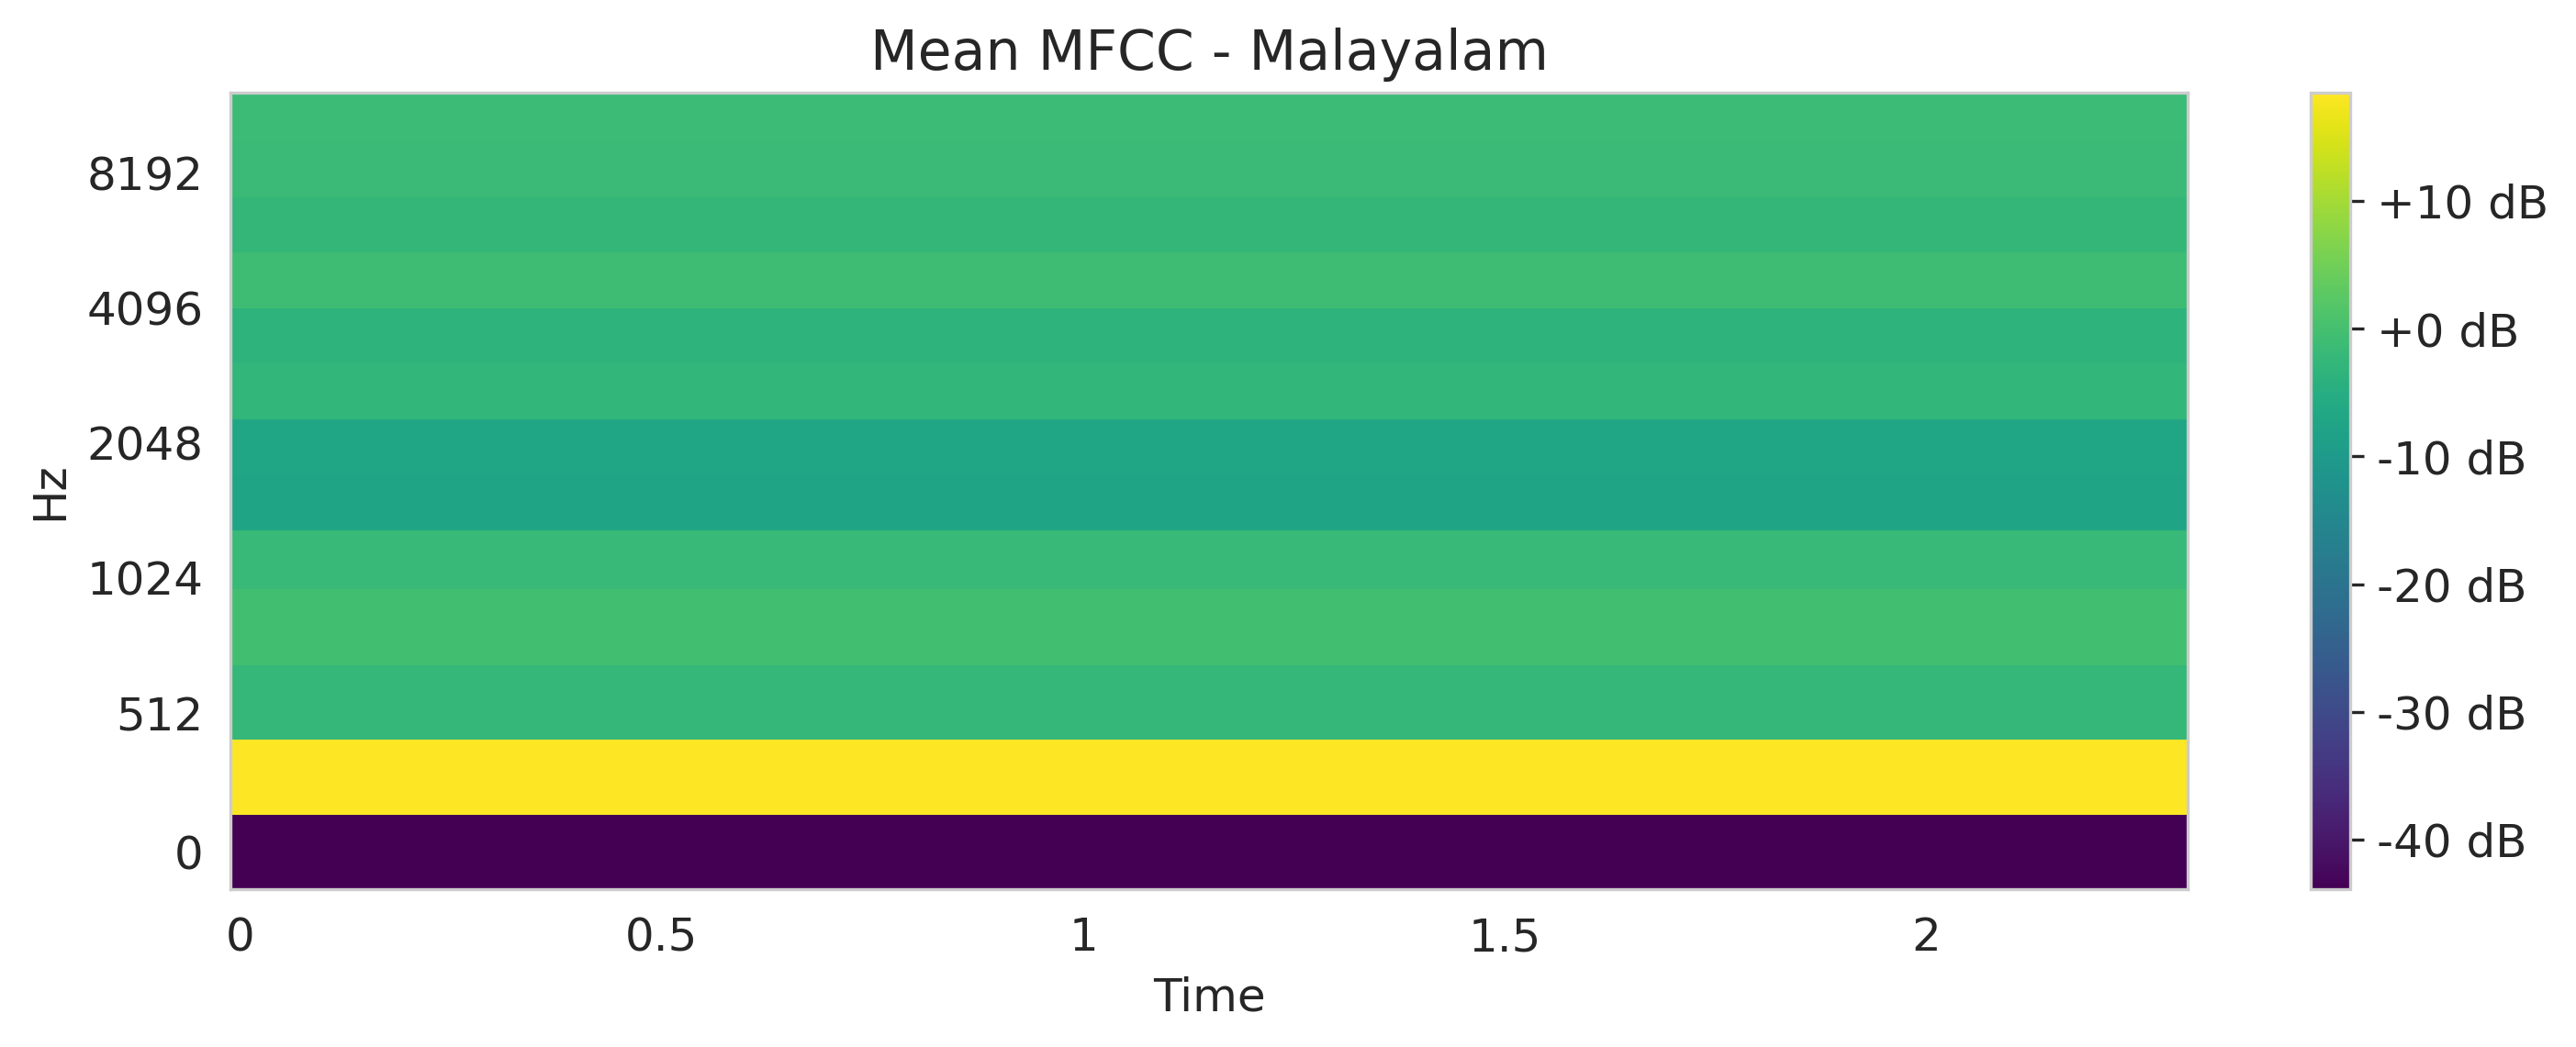

### Mean MFCC - Hindi

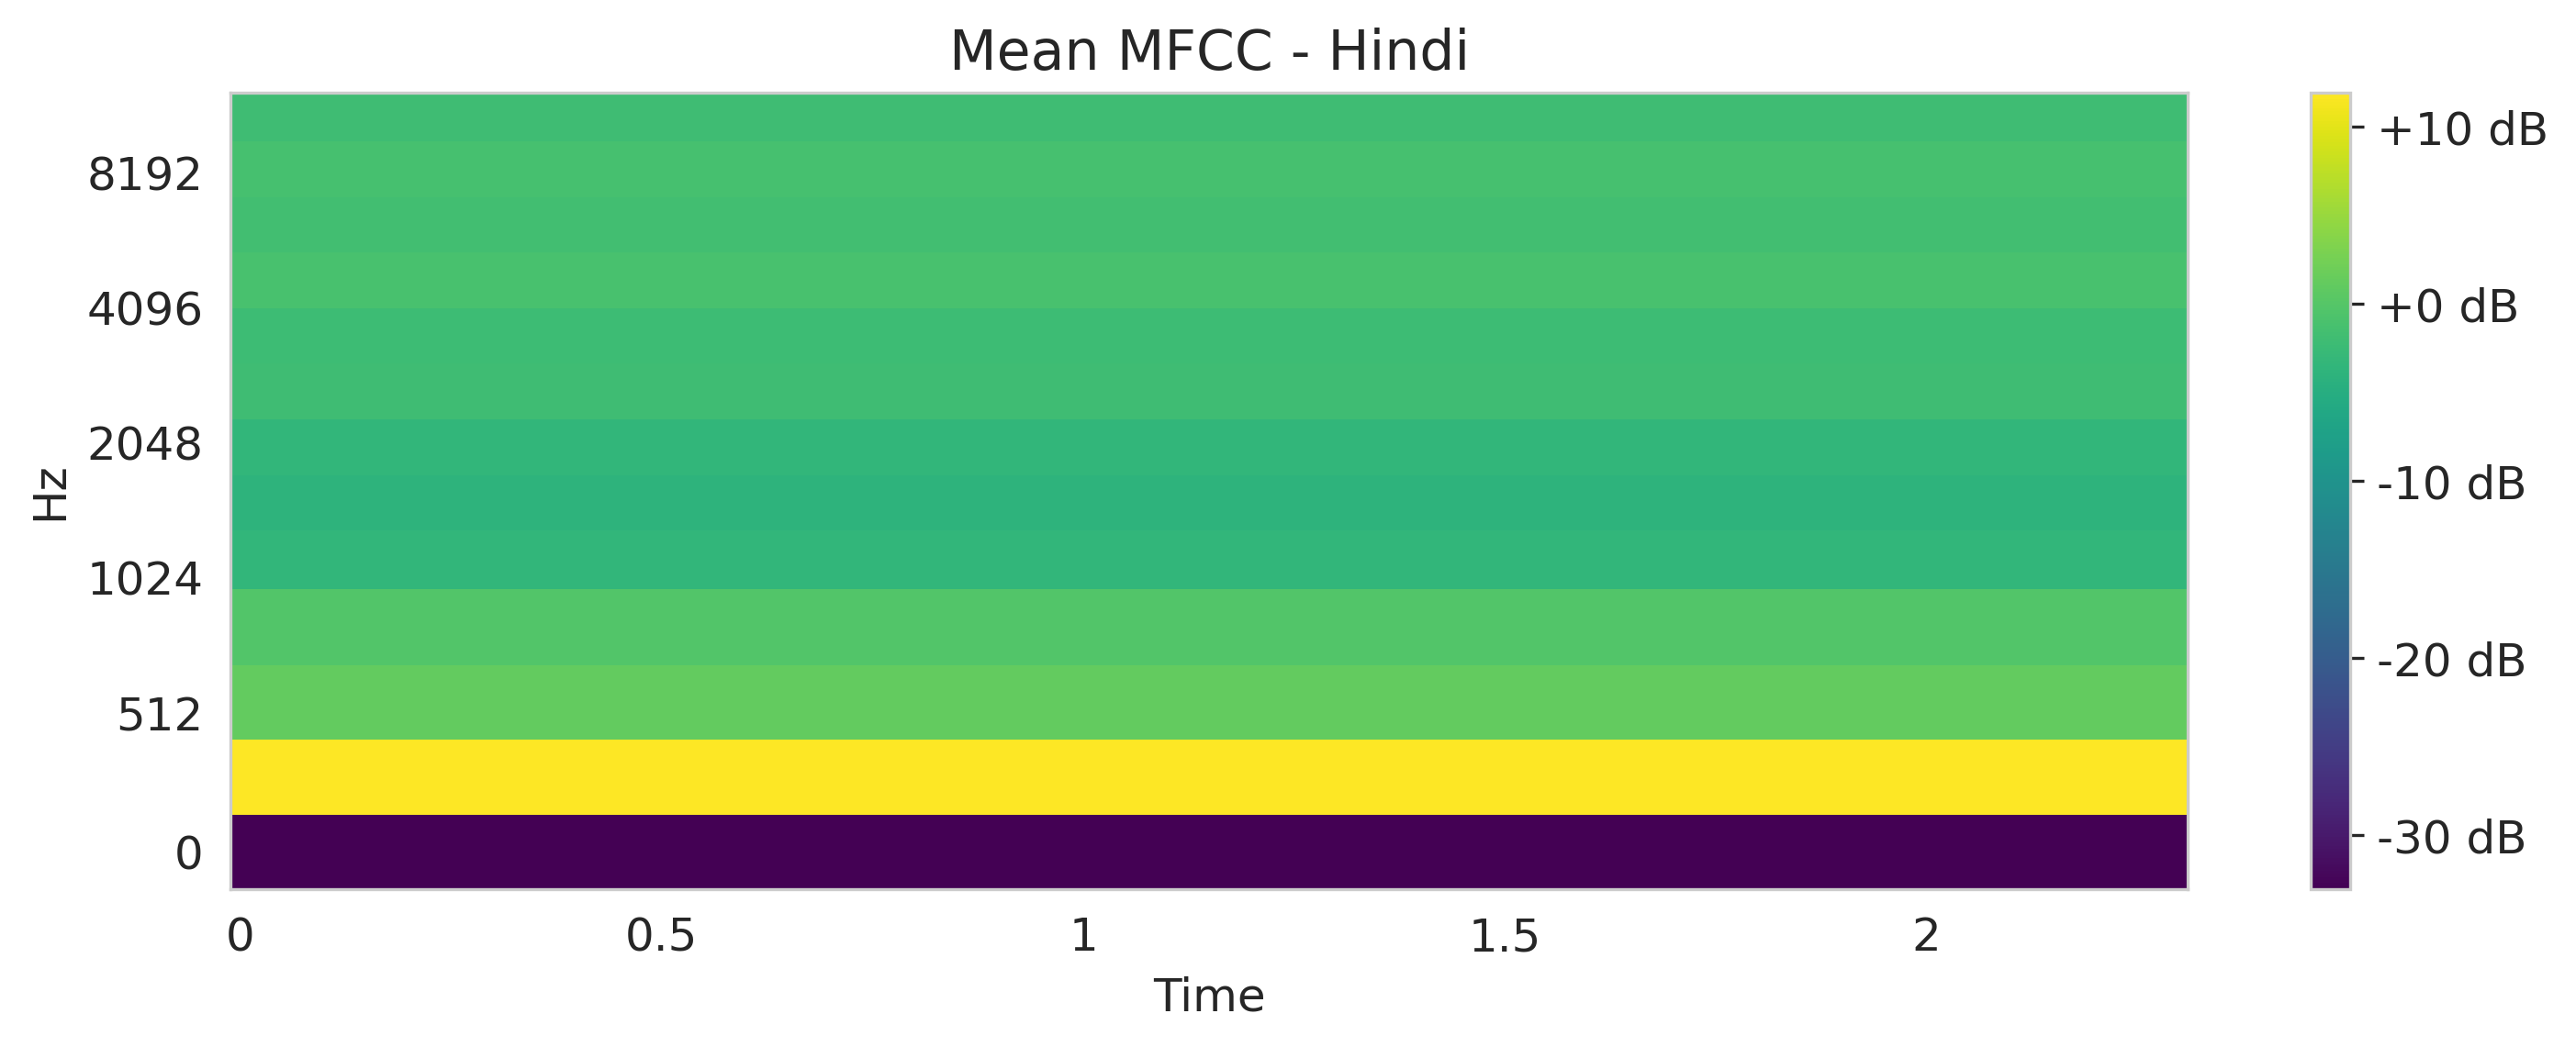

### Comparison of MFCC Coefficients Across Languages

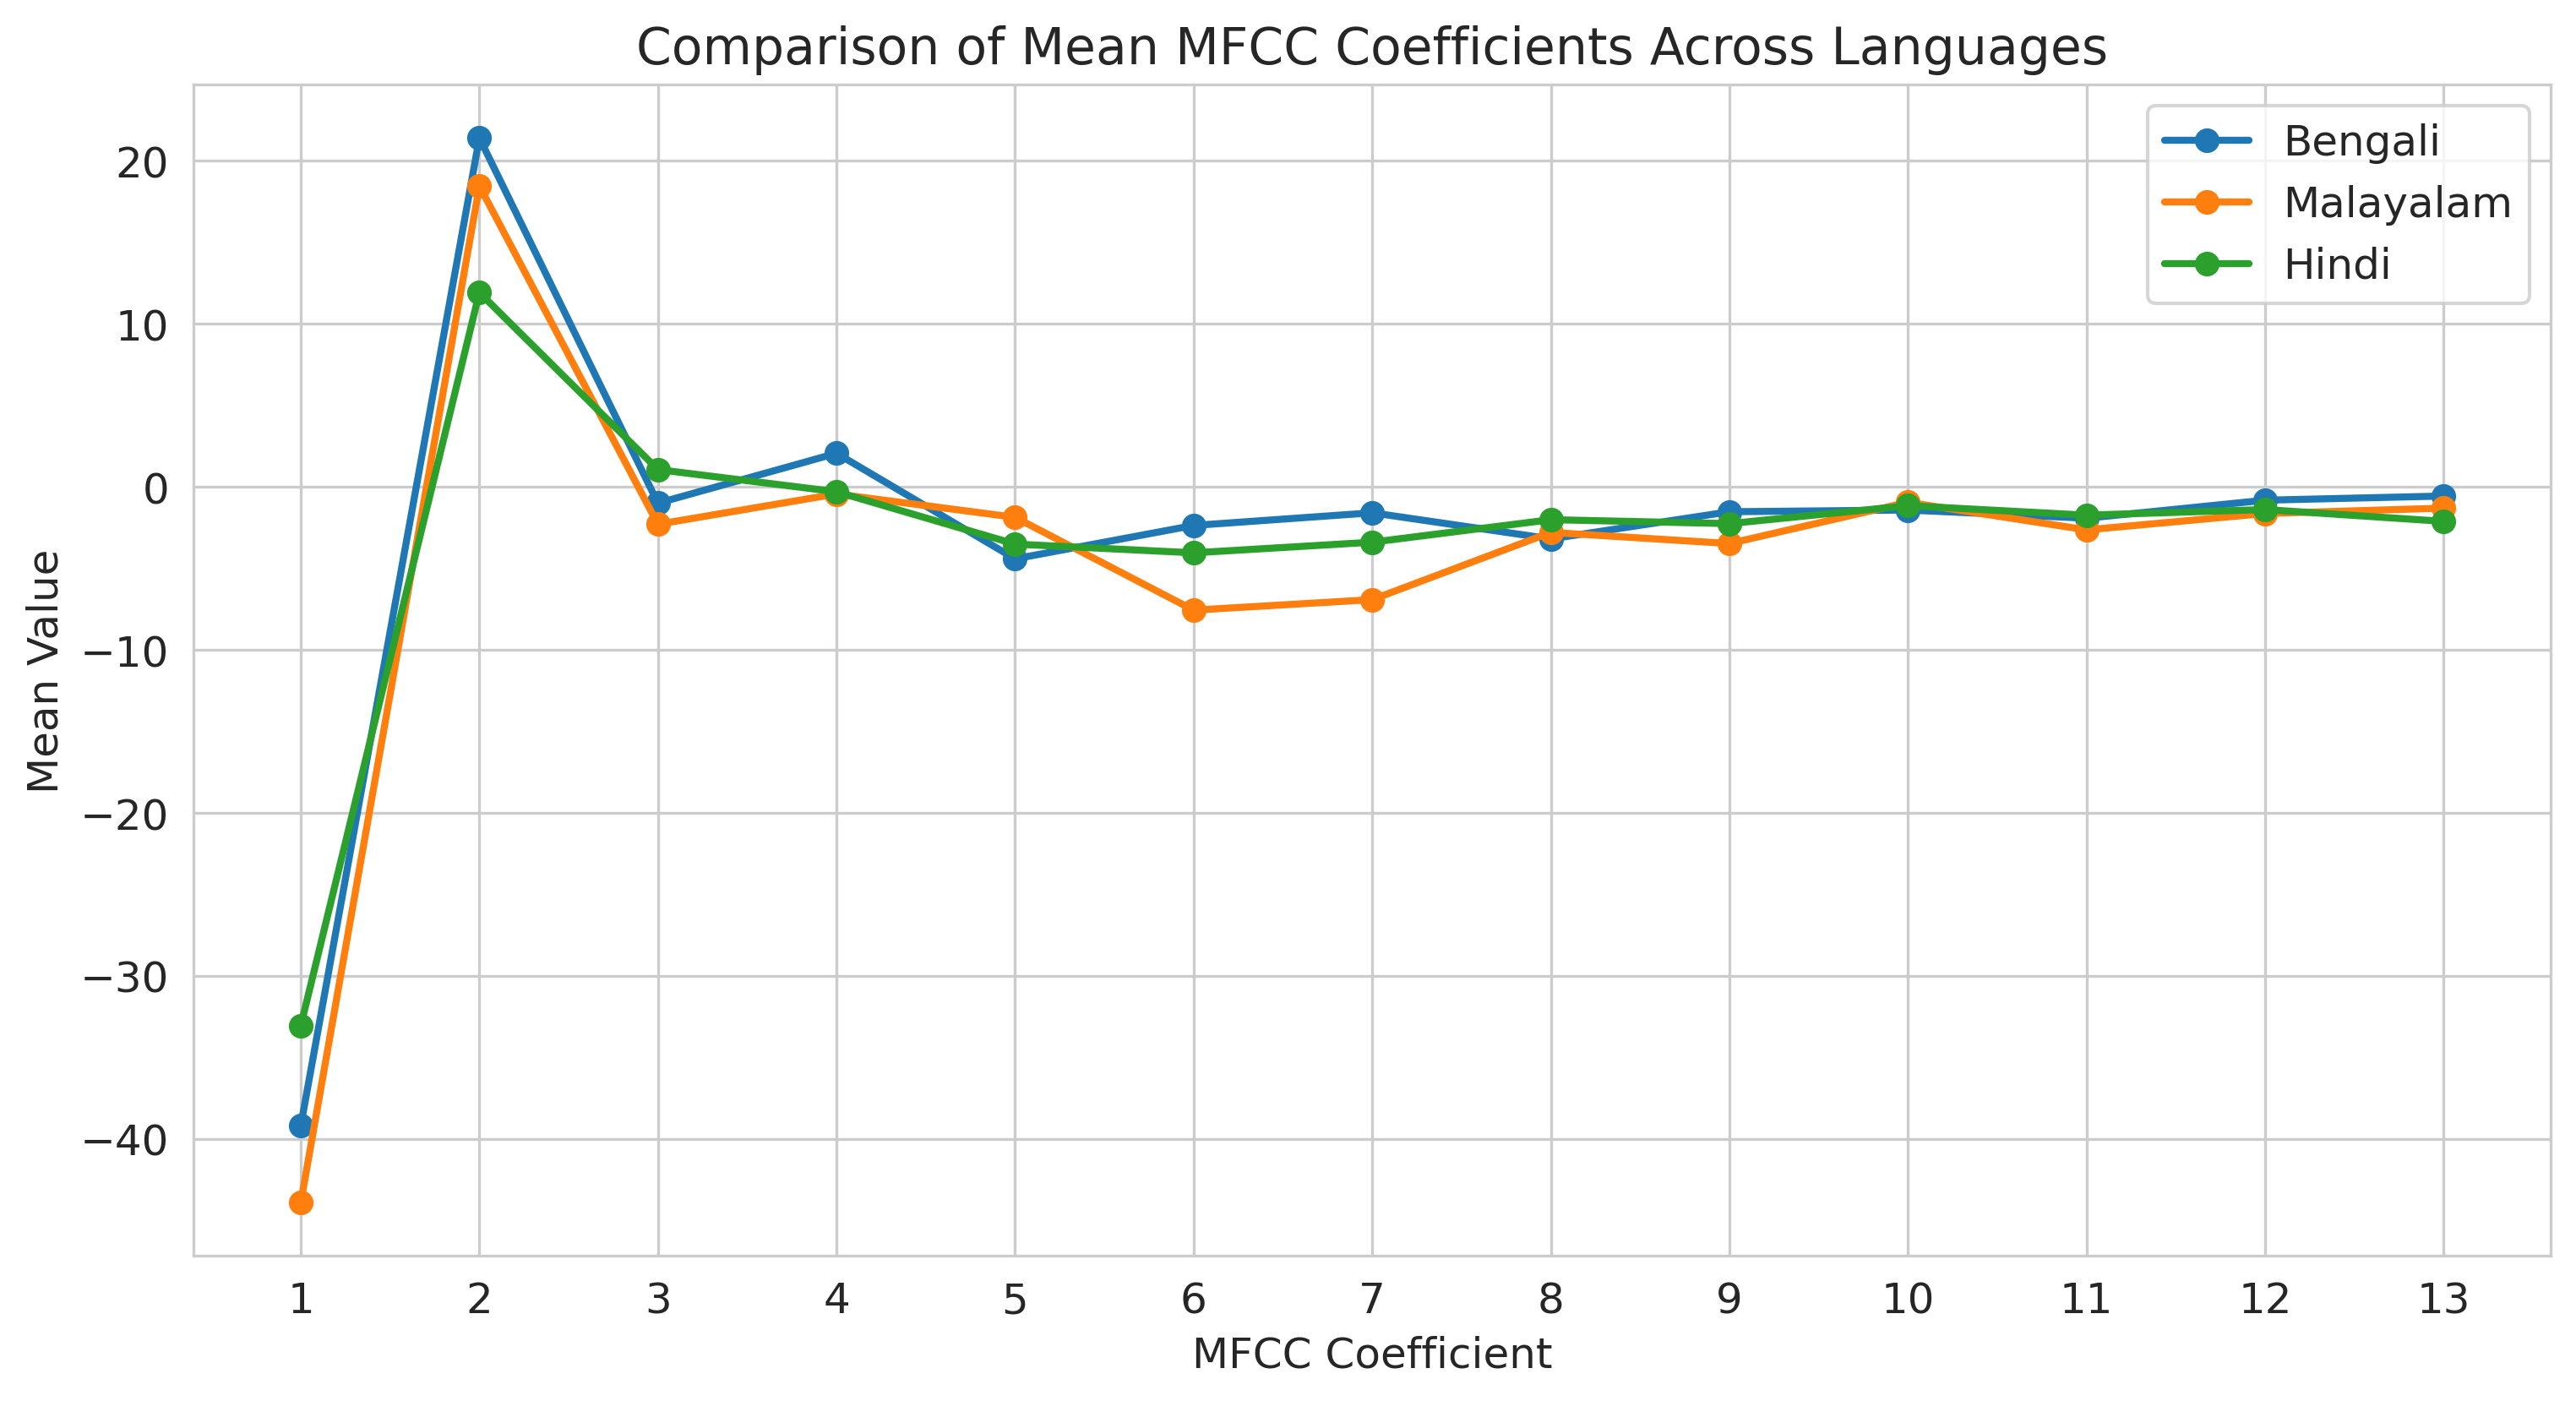

### Heatmap of Mean MFCC Coefficients

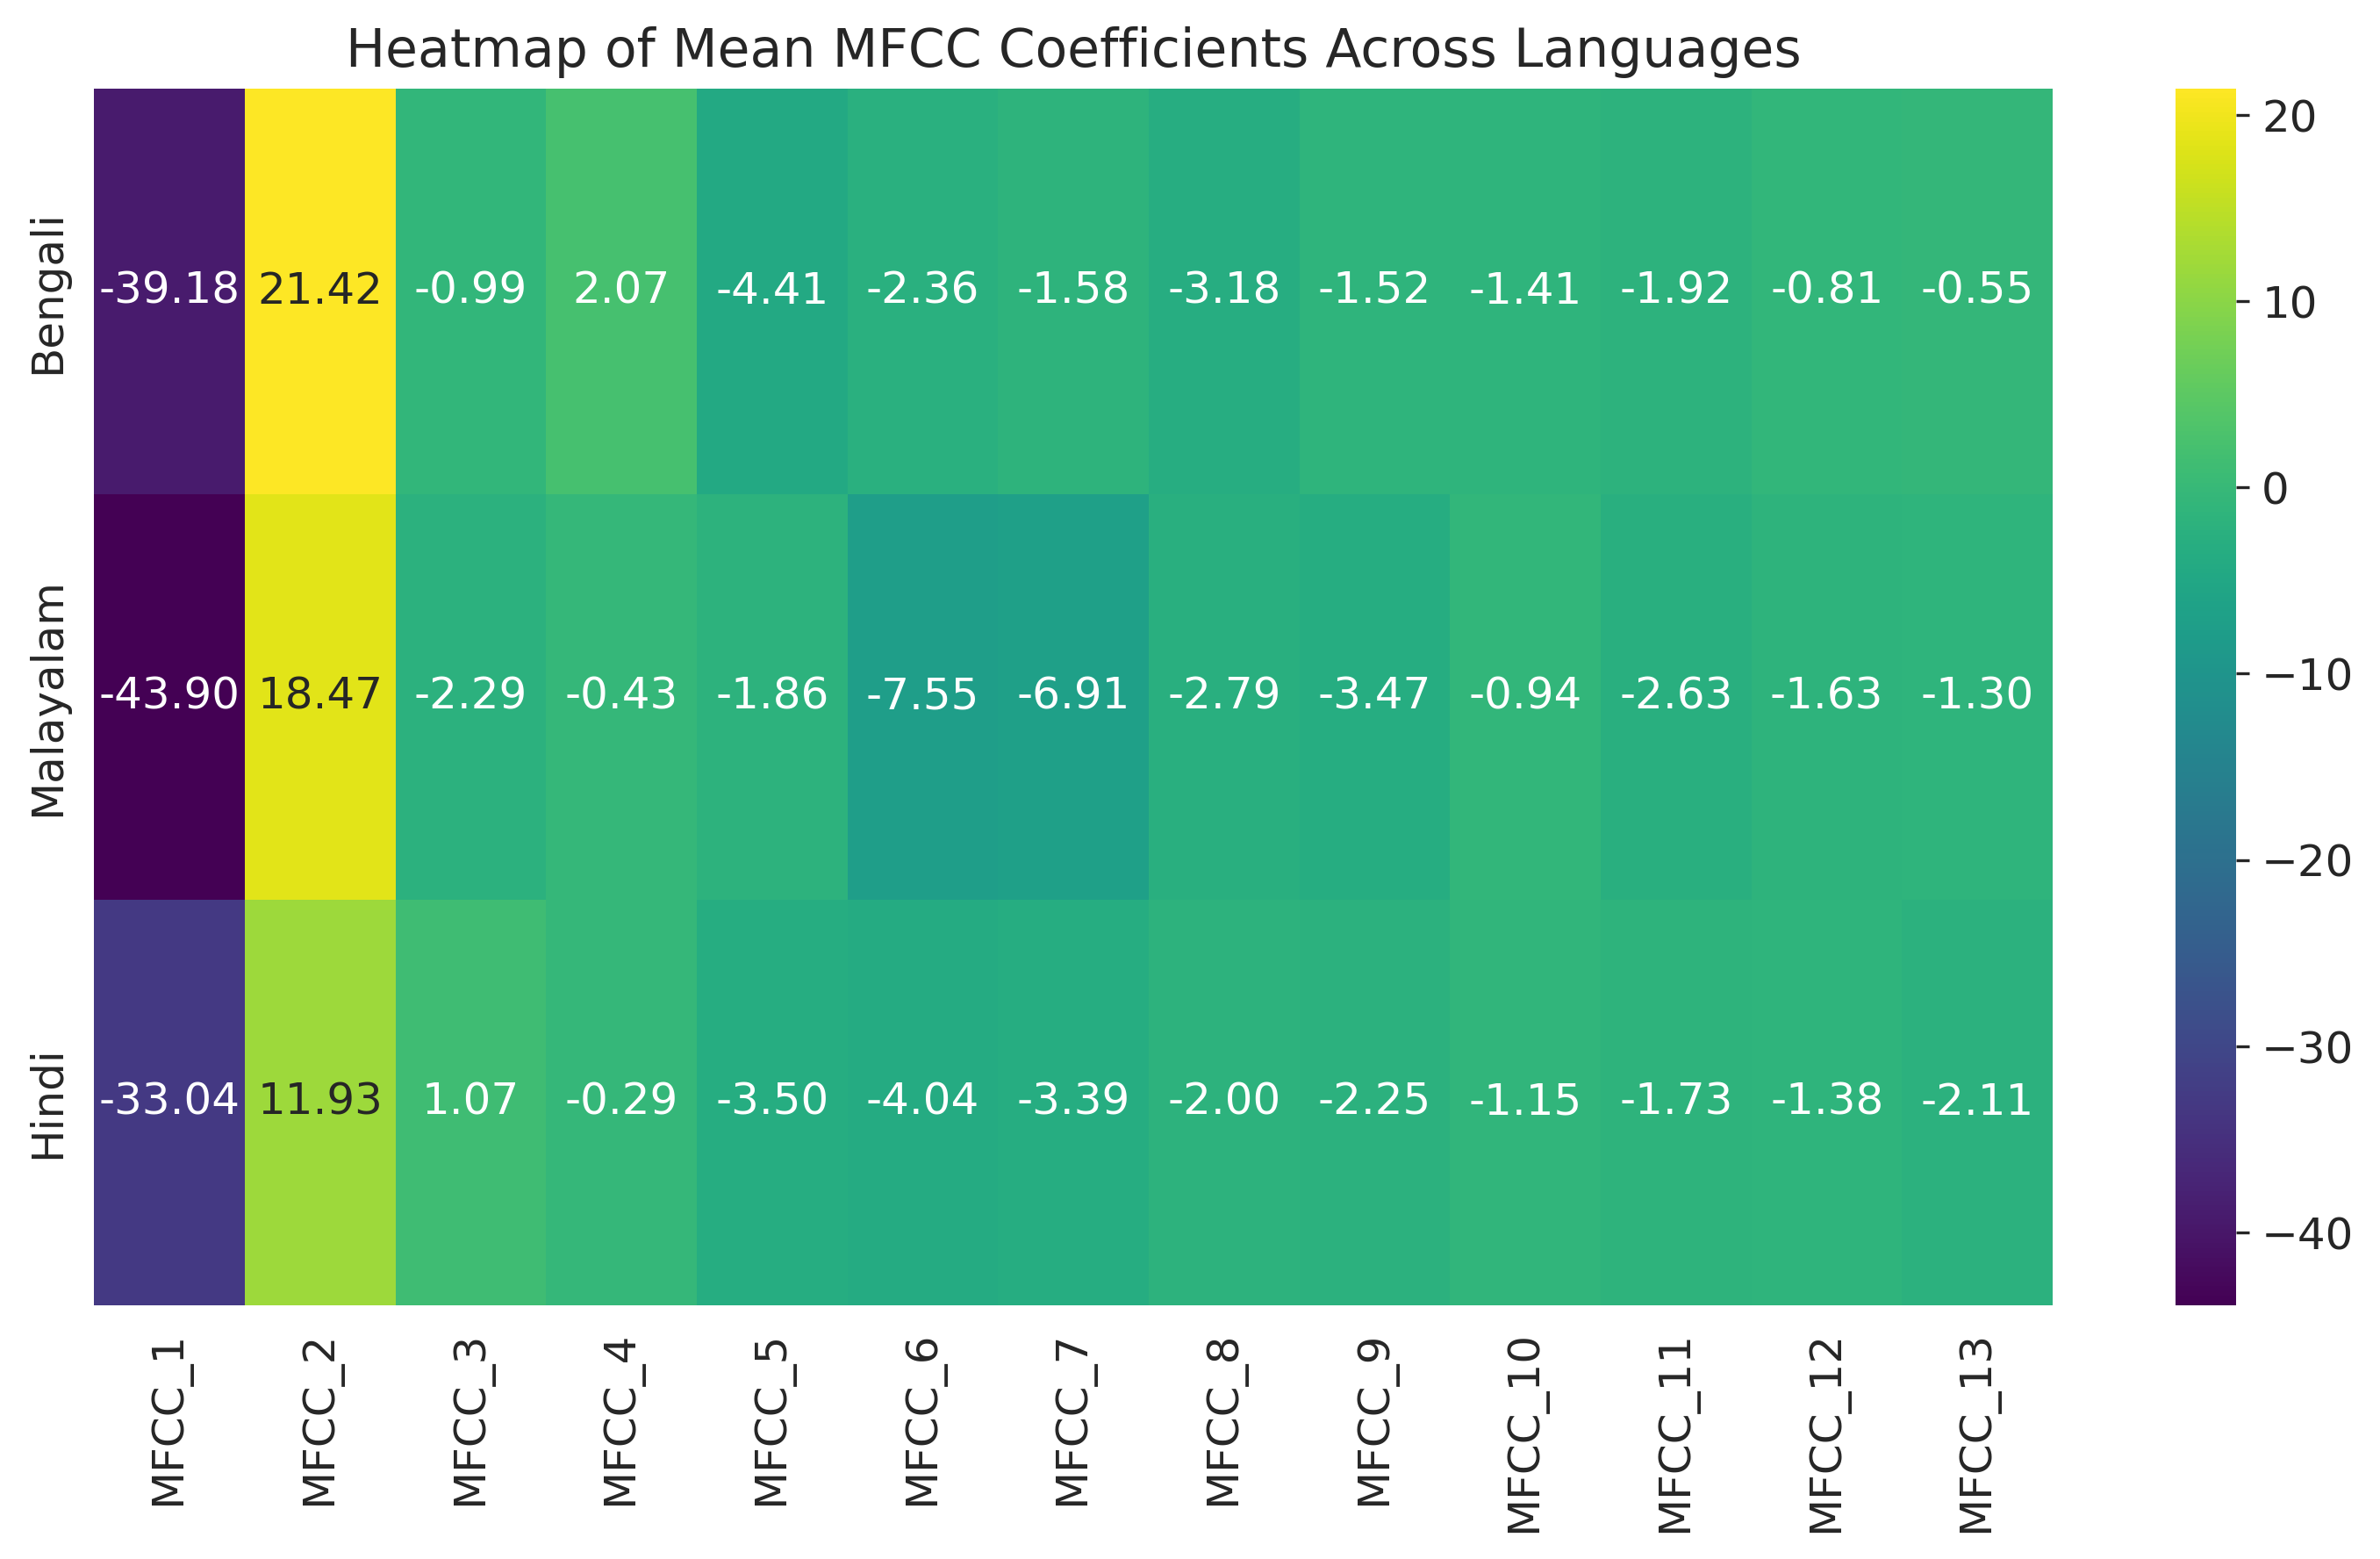

In [19]:
# Display results in the notebook
from IPython.display import Image, display, Markdown

# Show sample spectrograms
print("Sample MFCC Spectrograms:")
for language in selected_languages:
    sample_path = f'{results_dir}/spectrograms/{language}/{language}_sample_1.png'
    if os.path.exists(sample_path):
        display(Markdown(f"### {language} Sample MFCC Spectrogram"))
        display(Image(filename=sample_path))
    else:
        print(f"No spectrogram found for {language}")

# Show mean spectrograms
print("\nMean MFCC Spectrograms:")
for language in selected_languages:
    mean_path = f'{results_dir}/spectrograms/{language}/{language}_mean.png'
    if os.path.exists(mean_path):
        display(Markdown(f"### Mean MFCC - {language}"))
        display(Image(filename=mean_path))

# Show comparison plots
comparison_dir = f'{results_dir}/spectrograms/comparison'
if os.path.exists(comparison_dir):
    display(Markdown("### Comparison of MFCC Coefficients Across Languages"))
    display(Image(filename=f'{comparison_dir}/coefficient_comparison.png'))

    display(Markdown("### Heatmap of Mean MFCC Coefficients"))
    display(Image(filename=f'{comparison_dir}/mfcc_heatmap.png'))

In [21]:
def perform_statistical_analysis(languages=['Bengali', 'Malayalam', 'Hindi'],
                               features_dir=None, stats_dir=None):

    # Set default directories if not provided
    if features_dir is None:
        features_dir = f"{results_dir}/features"
    if stats_dir is None:
        stats_dir = f"{results_dir}/stats"
        os.makedirs(stats_dir, exist_ok=True)

    print(f"=== Performing Statistical Analysis on {', '.join(languages)} ===")

    # Load MFCC data for each language
    language_mfccs = {}

    for language in languages:
        lang_dir = os.path.join(features_dir, language)
        if not os.path.exists(lang_dir):
            print(f"No feature directory found for {language}")
            continue

        feature_files = [f for f in os.listdir(lang_dir) if f.endswith('.json')]
        if not feature_files:
            print(f"No feature files found for {language}")
            continue

        print(f"Loading {len(feature_files)} feature files for {language}...")

        # Load and process each file
        mfcc_means = []
        for file in feature_files:
            try:
                with open(os.path.join(lang_dir, file), 'r') as f:
                    data = json.load(f)

                mfccs = np.array(data['mfccs'])
                # Calculate mean across time dimension
                mfcc_means.append(np.mean(mfccs, axis=1))
            except Exception as e:
                print(f"Error processing file {file}: {e}")

        if mfcc_means:
            language_mfccs[language] = np.array(mfcc_means)
            print(f"Successfully loaded {len(mfcc_means)} samples for {language}")

    # Proceed with analysis if we have data for at least 2 languages
    if len(language_mfccs) < 2:
        print("Insufficient data for statistical comparison. Need at least 2 languages.")
        return None

    # Calculate statistics for each language
    language_stats = {}
    for language, means in language_mfccs.items():
        language_stats[language] = {
            'means': means,
            'mean': np.mean(means, axis=0),
            'variance': np.var(means, axis=0),
            'std': np.std(means, axis=0)
        }

    # Create statistics table
    stats_rows = []
    for language, stats in language_stats.items():
        for i, (m, v, s) in enumerate(zip(stats['mean'], stats['variance'], stats['std'])):
            stats_rows.append({
                'Language': language,
                'Coefficient': f'MFCC_{i+1}',
                'Mean': m,
                'Variance': v,
                'Std': s
            })

    stats_df = pd.DataFrame(stats_rows)
    stats_csv = os.path.join(stats_dir, 'mfcc_stats.csv')
    stats_df.to_csv(stats_csv, index=False)
    print(f"Saved statistical summary to {stats_csv}")

    # Perform t-tests between language pairs
    ttest_rows = []
    languages = list(language_stats.keys())

    for i in range(len(languages)):
        for j in range(i+1, len(languages)):
            lang1, lang2 = languages[i], languages[j]
            means1 = language_stats[lang1]['means']
            means2 = language_stats[lang2]['means']

            # For each coefficient
            n_mfcc = means1.shape[1]
            significant_count = 0

            for coef in range(n_mfcc):
                t_stat, p_val = ttest_ind(means1[:, coef], means2[:, coef], equal_var=False)
                significant = p_val < 0.05
                if significant:
                    significant_count += 1

                ttest_rows.append({
                    'Language_Pair': f"{lang1}-{lang2}",
                    'Coefficient': f'MFCC_{coef+1}',
                    't_statistic': t_stat,
                    'p_value': p_val,
                    'Significant': significant
                })

            print(f"{lang1} vs {lang2}: {significant_count}/{n_mfcc} coefficients show significant differences")

    ttest_df = pd.DataFrame(ttest_rows)
    ttest_csv = os.path.join(stats_dir, 'ttest_results.csv')
    ttest_df.to_csv(ttest_csv, index=False)
    print(f"Saved t-test results to {ttest_csv}")

    # Run PCA analysis
    X = []
    labels = []

    for language, stats in language_stats.items():
        for mean_values in stats['means']:
            X.append(mean_values)
            labels.append(language)

    X = np.array(X)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Run PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Plot PCA results
    plt.figure(figsize=(10, 8))

    # Create custom colors for scatterplot
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i, language in enumerate(language_stats.keys()):
        mask = [l == language for l in labels]
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=language,
            color=colors[i % len(colors)],
            alpha=0.7,
            s=100
        )

    # Add explained variance
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.title('PCA of MFCC Features by Language')
    plt.legend()
    plt.grid(True)

    # Save PCA plot
    pca_file = os.path.join(stats_dir, 'pca_analysis.png')
    plt.savefig(pca_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved PCA visualization to {pca_file}")

    # Create heatmap of mean coefficients
    plt.figure(figsize=(12, 6))
    mean_data = {}
    for language, stats in language_stats.items():
        mean_data[language] = stats['mean']

    df = pd.DataFrame(mean_data).T
    df.columns = [f'MFCC_{i+1}' for i in range(df.shape[1])]

    sns.heatmap(df, annot=True, cmap='viridis', fmt='.2f')
    plt.title('Heatmap of Mean MFCC Coefficients Across Languages')

    heatmap_file = os.path.join(stats_dir, 'mfcc_heatmap.png')
    plt.savefig(heatmap_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved coefficient heatmap to {heatmap_file}")

    print("\n=== Statistical Analysis Complete ===")

    # Return the analysis results
    return {
        'language_stats': language_stats,
        'stats_df': stats_df,
        'ttest_df': ttest_df,
        'pca_results': {
            'X_pca': X_pca,
            'labels': labels,
            'explained_variance': pca.explained_variance_ratio_
        }
    }

=== Performing Statistical Analysis on Bengali, Malayalam, Hindi ===
Loading 2019 feature files for Bengali...
Successfully loaded 2019 samples for Bengali
Loading 2020 feature files for Malayalam...
Successfully loaded 2020 samples for Malayalam
Loading 2018 feature files for Hindi...
Successfully loaded 2018 samples for Hindi
Saved statistical summary to /content/indian_languages_audio/results/stats/mfcc_stats.csv
Bengali vs Malayalam: 13/13 coefficients show significant differences
Bengali vs Hindi: 13/13 coefficients show significant differences
Malayalam vs Hindi: 12/13 coefficients show significant differences
Saved t-test results to /content/indian_languages_audio/results/stats/ttest_results.csv
Saved PCA visualization to /content/indian_languages_audio/results/stats/pca_analysis.png
Saved coefficient heatmap to /content/indian_languages_audio/results/stats/mfcc_heatmap.png

=== Statistical Analysis Complete ===


### PCA Analysis

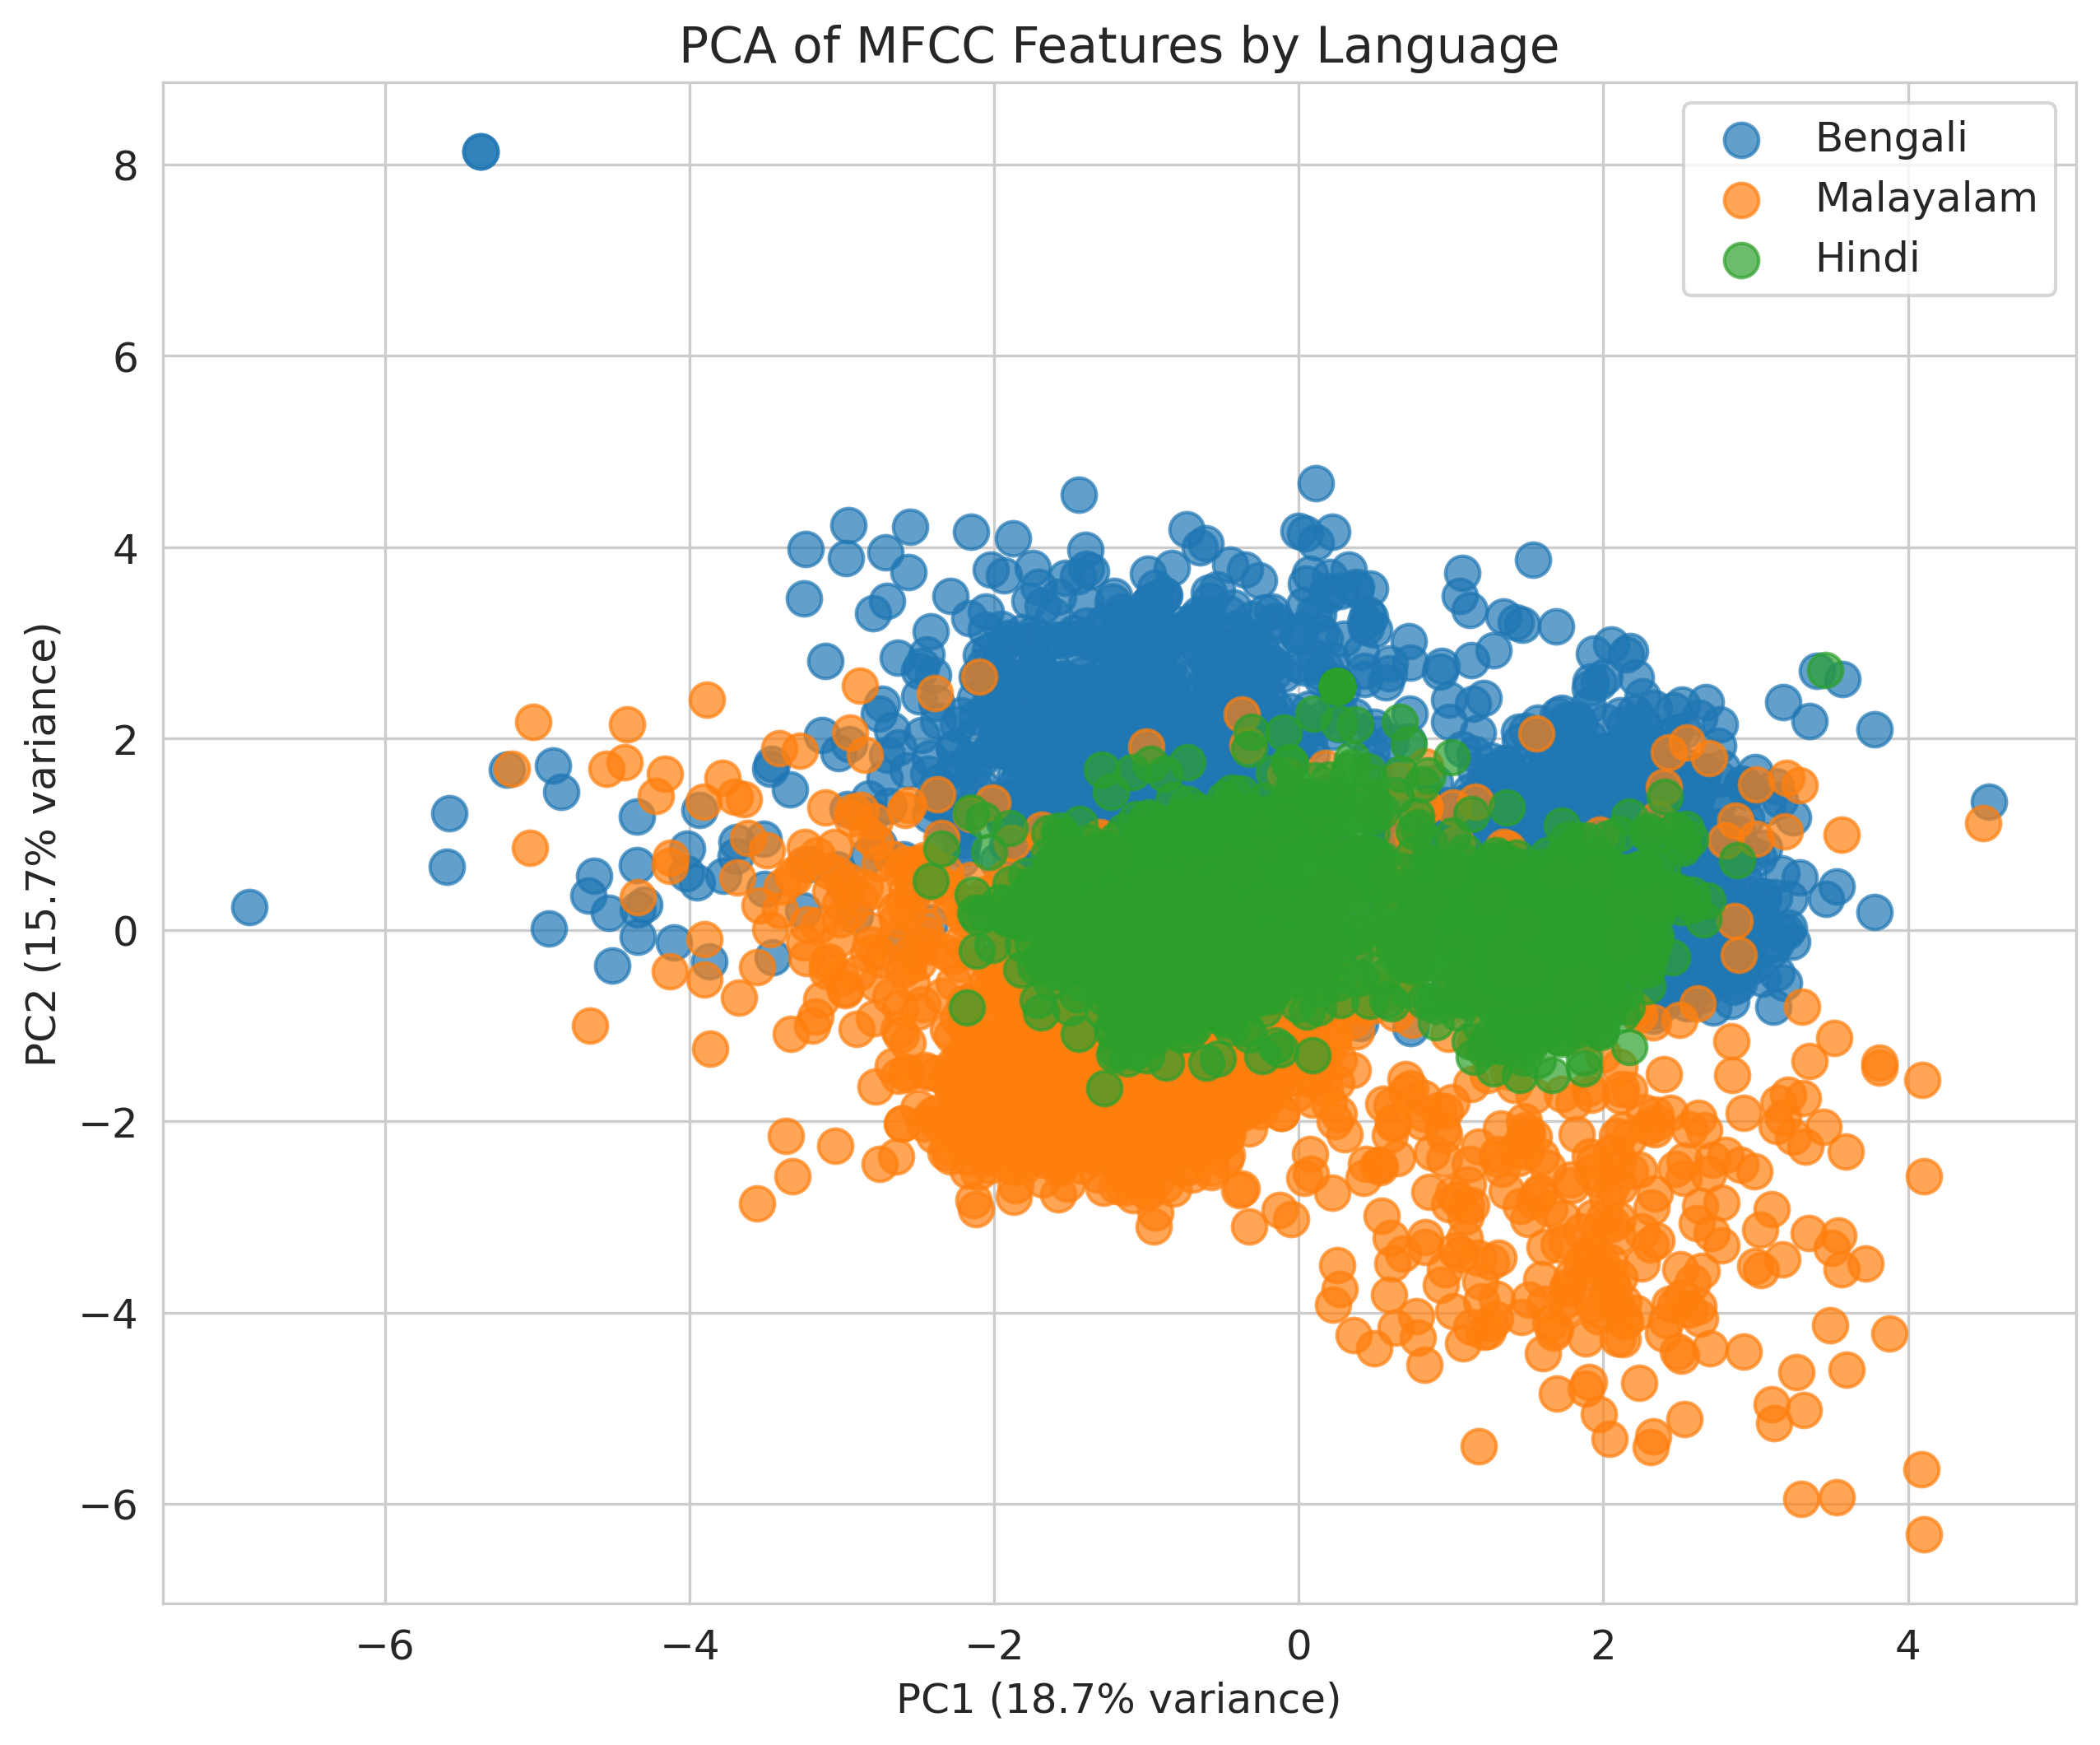

### MFCC Coefficient Heatmap

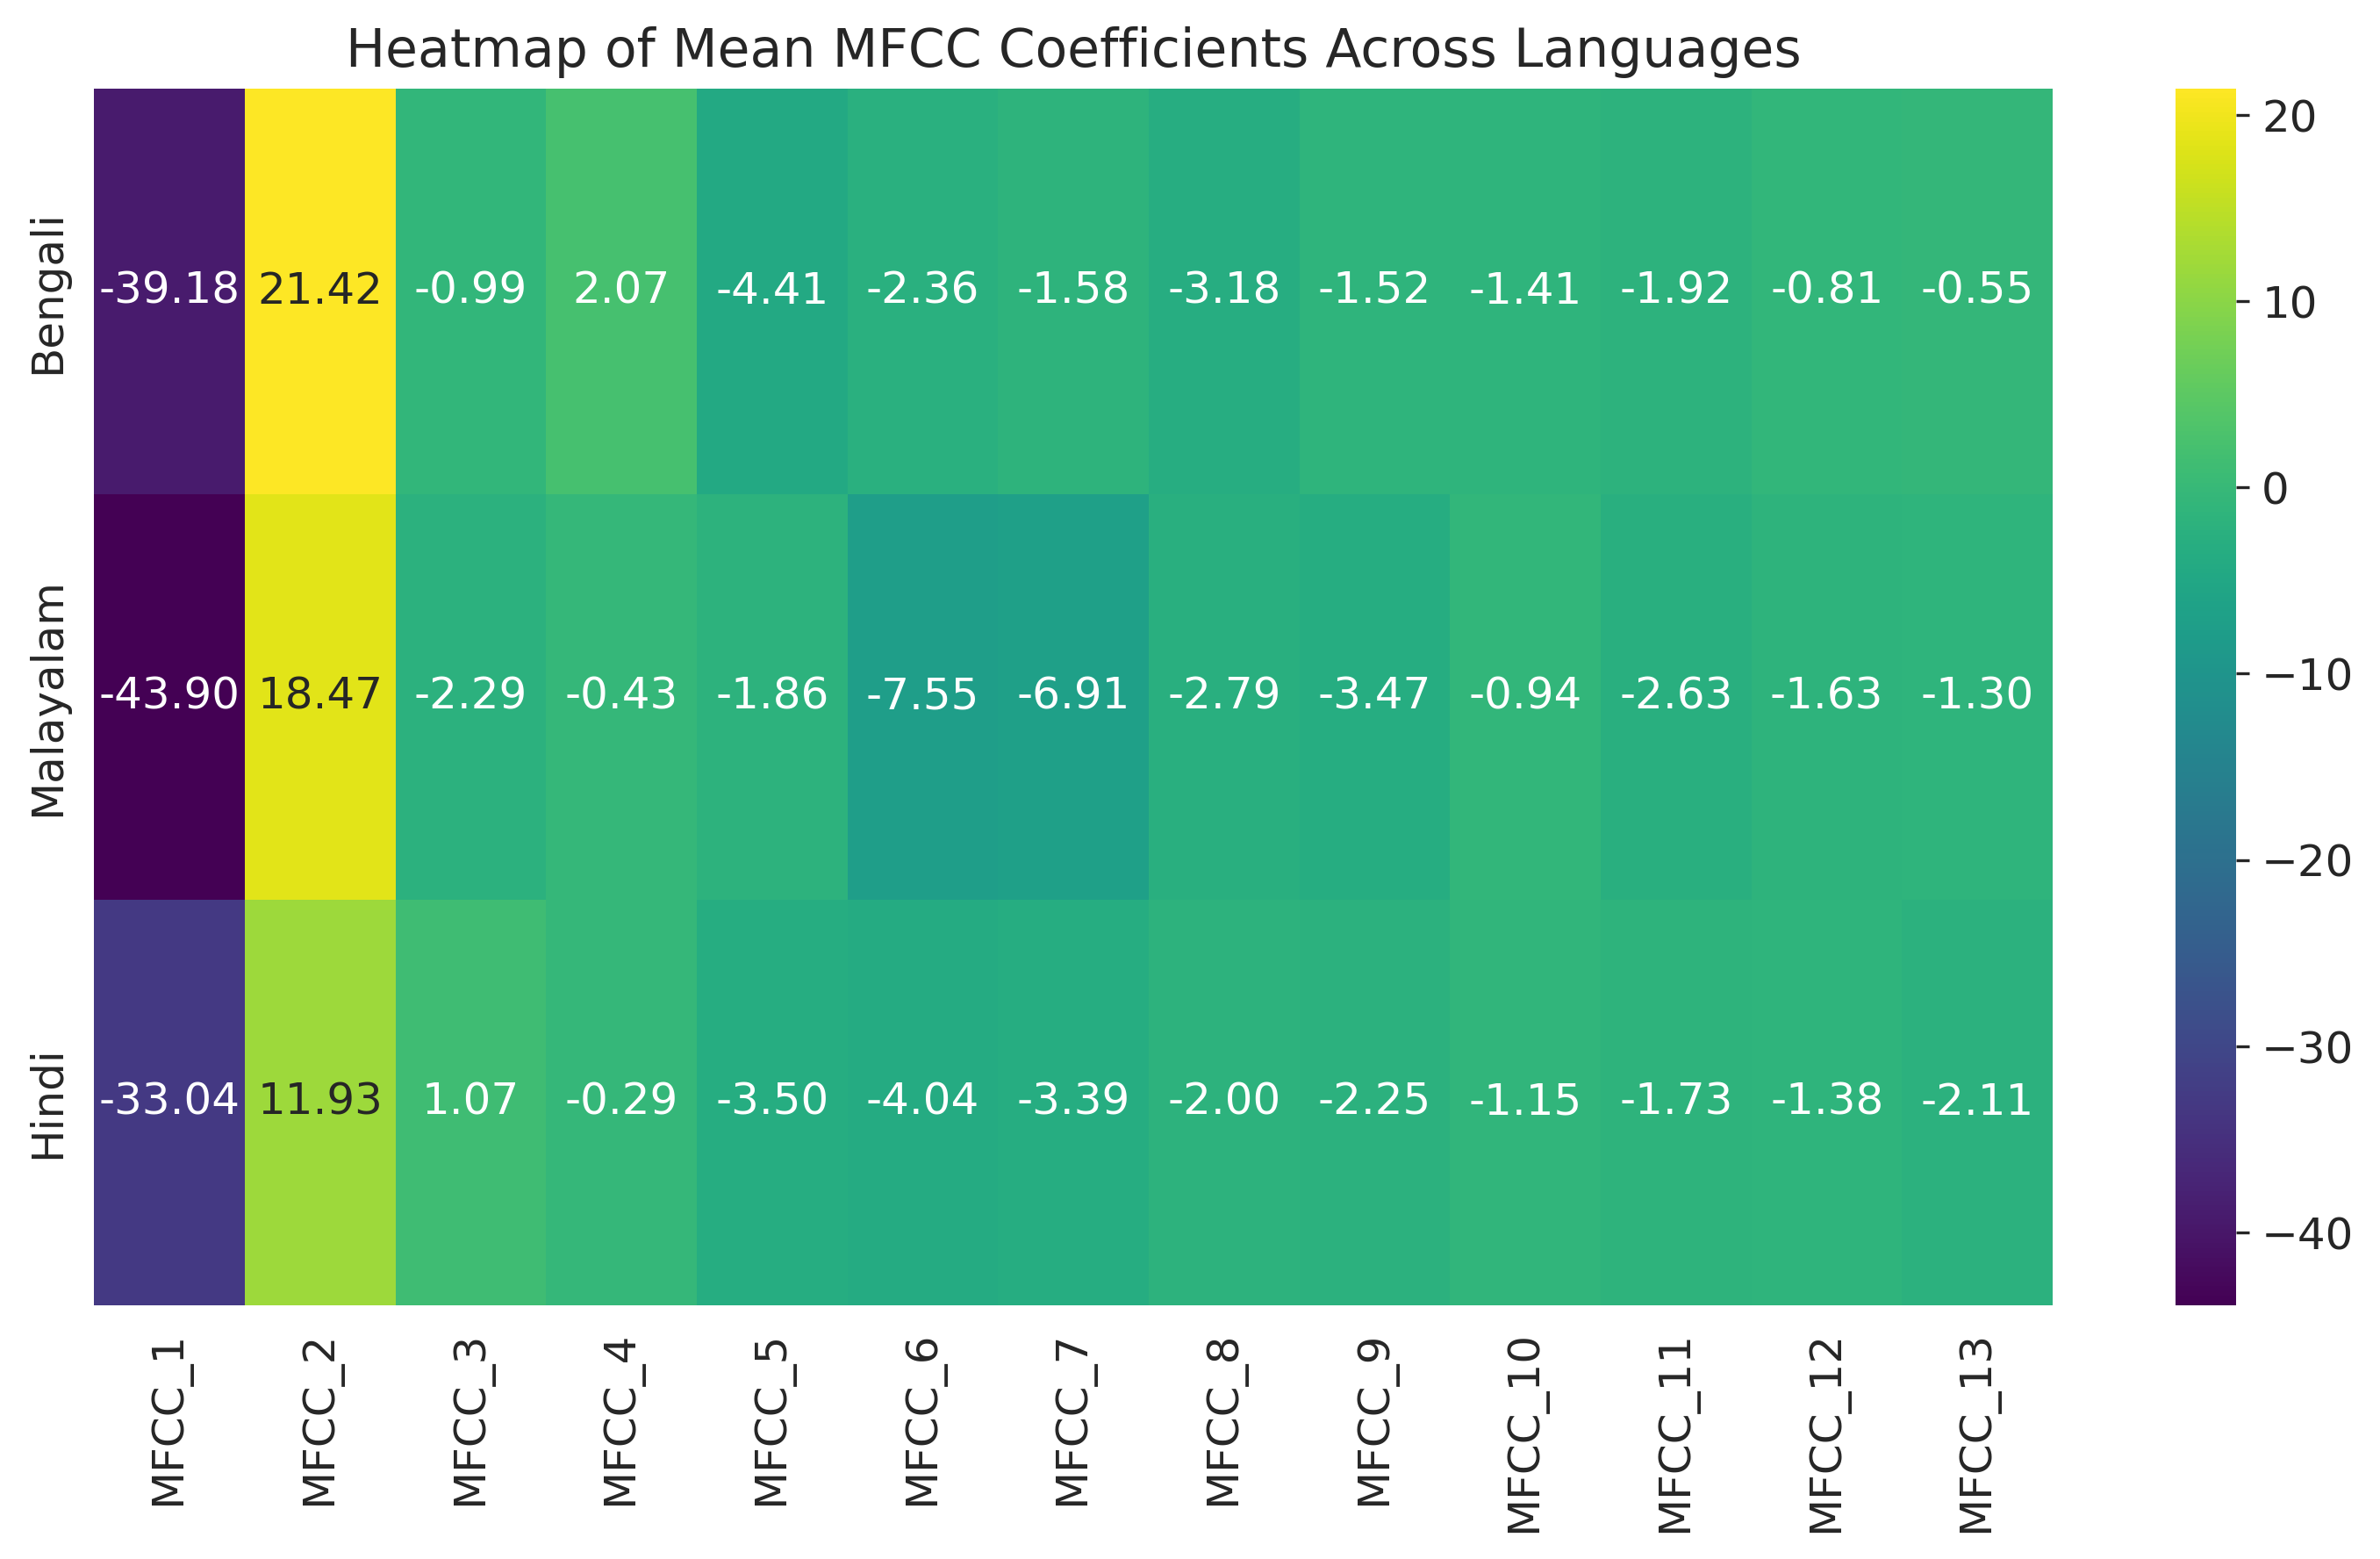

### MFCC Statistics by Language

Language,Bengali,Hindi,Malayalam
Coefficient,,,
MFCC_1,-39.179327,-33.043130,-43.895235
MFCC_10,-1.412580,-1.145003,-0.938084
MFCC_11,-1.916667,-1.728811,-2.631157
MFCC_12,-0.810041,-1.383663,-1.626123
MFCC_13,-0.554557,-2.109324,-1.297291
MFCC_2,21.415152,11.931846,18.465661
MFCC_3,-0.991921,1.067585,-2.285745
MFCC_4,2.067332,-0.292736,-0.426531
MFCC_5,-4.407307,-3.502832,-1.861643


### Statistical Significance Summary

,Language Pair,Number of Significant Coefficients
0,Bengali-Hindi,13
1,Bengali-Malayalam,13
2,Malayalam-Hindi,12


In [22]:
# Call the statistical analysis function
analysis_results = perform_statistical_analysis(
    languages=['Bengali', 'Malayalam', 'Hindi'],
    features_dir=f"{results_dir}/features",
    stats_dir=f"{results_dir}/stats"
)

# Display results
if analysis_results:
    from IPython.display import Image, display, Markdown

    # Show PCA plot
    display(Markdown("### PCA Analysis"))
    display(Image(filename=f"{results_dir}/stats/pca_analysis.png"))

    # Show heatmap
    display(Markdown("### MFCC Coefficient Heatmap"))
    display(Image(filename=f"{results_dir}/stats/mfcc_heatmap.png"))

    # Show statistical summary
    display(Markdown("### MFCC Statistics by Language"))
    pivot_df = analysis_results['stats_df'].pivot(index='Coefficient', columns='Language', values='Mean')
    display(pivot_df)

    # Show significant differences
    display(Markdown("### Statistical Significance Summary"))
    sig_df = analysis_results['ttest_df'][analysis_results['ttest_df']['Significant'] == True]
    sig_summary = sig_df.groupby('Language_Pair').size().reset_index()
    sig_summary.columns = ['Language Pair', 'Number of Significant Coefficients']
    display(sig_summary)

In [24]:
!zip -r results.zip /content/indian_languages_audio/results


Streaming output truncated to the last 5000 lines.
  adding: content/indian_languages_audio/results/features/Bengali/10063.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/19166.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/21308.json (deflated 52%)
  adding: content/indian_languages_audio/results/features/Bengali/1918.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/10174.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/14474.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/20594.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/10023.json (deflated 60%)
  adding: content/indian_languages_audio/results/features/Bengali/24290.json (deflated 53%)
  adding: content/indian_languages_audio/results/features/Bengali/4928.json (deflated 53%)
  adding: content/indian_langua

# Task 2 B

In [35]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from torch.utils.data import Dataset, DataLoader


In [36]:
features_dir = '/content/indian_languages_audio/results/features'  # or wherever your features are saved
selected_languages = ['Bengali', 'Malayalam', 'Hindi']
n_mfcc = 13
batch_size = 32
epochs = 30
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [37]:
#Load Data
X = []
y = []

for language in selected_languages:
    lang_dir = os.path.join(features_dir, language)
    feature_files = [f for f in os.listdir(lang_dir) if f.endswith('.json')]

    for file in feature_files:
        with open(os.path.join(lang_dir, file), 'r') as f:
            data = json.load(f)
        mfccs = np.array(data['mfccs'])
        mfcc_mean = np.mean(mfccs, axis=1)  # mean over time axis
        X.append(mfcc_mean)
        y.append(language)

X = np.array(X)
y = np.array(y)

print(f"Loaded {len(X)} samples.")



Loaded 6057 samples.


In [38]:
#Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [52]:
class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MFCCDataset(X_train, y_train)
test_dataset = MFCCDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


#SVM Classifier\
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm*100:.2f}%")

#Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf*100:.2f}%")
class LanguageClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LanguageClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = LanguageClassifier(input_dim=n_mfcc, num_classes=num_classes).to(device)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

SVM Accuracy: 95.71%
Random Forest Accuracy: 97.52%
Epoch 1/30, Loss: 1.0055
Epoch 2/30, Loss: 0.5604
Epoch 3/30, Loss: 0.3786
Epoch 4/30, Loss: 0.3160
Epoch 5/30, Loss: 0.2894
Epoch 6/30, Loss: 0.2378
Epoch 7/30, Loss: 0.2234
Epoch 8/30, Loss: 0.2136
Epoch 9/30, Loss: 0.1987
Epoch 10/30, Loss: 0.1927
Epoch 11/30, Loss: 0.1804
Epoch 12/30, Loss: 0.1789
Epoch 13/30, Loss: 0.1730
Epoch 14/30, Loss: 0.1671
Epoch 15/30, Loss: 0.1456
Epoch 16/30, Loss: 0.1554
Epoch 17/30, Loss: 0.1426
Epoch 18/30, Loss: 0.1428
Epoch 19/30, Loss: 0.1331
Epoch 20/30, Loss: 0.1381
Epoch 21/30, Loss: 0.1408
Epoch 22/30, Loss: 0.1298
Epoch 23/30, Loss: 0.1260
Epoch 24/30, Loss: 0.1257
Epoch 25/30, Loss: 0.1225
Epoch 26/30, Loss: 0.1198
Epoch 27/30, Loss: 0.1140
Epoch 28/30, Loss: 0.1128
Epoch 29/30, Loss: 0.1147
Epoch 30/30, Loss: 0.1124


In [53]:
model.eval()
all_preds_nn = []
all_labels_nn = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds_nn.extend(preds.cpu().numpy())
        all_labels_nn.extend(labels.cpu().numpy())

acc_nn = accuracy_score(all_labels_nn, all_preds_nn)
print(f"\n Simple Neural Network Accuracy: {acc_nn*100:.2f}%")


 Simple Neural Network Accuracy: 97.36%


In [58]:
def plot_conf_matrix(y_true, y_pred, labels, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    plt.title(title)
    plt.savefig(os.path.join(save_path, filename))
    plt.show()
    plt.close()

def show_sample_predictions(y_true, y_pred, label_encoder, model_name, num_samples=10):
    print(f"\nSample Predictions for {model_name}:\n")
    idx_to_label = {idx: label for idx, label in enumerate(label_encoder.classes_)}
    for i in range(min(len(y_true), num_samples)):
        true_label = idx_to_label[y_true[i]]
        pred_label = idx_to_label[y_pred[i]]
        print(f"Actual: {true_label} --- Predicted: {pred_label}")

save_path = '/content/drive/MyDrive/SU_2/results'
os.makedirs(save_path, exist_ok=True)


 SVM Accuracy: 95.71%

Sample Predictions for SVM:

Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali


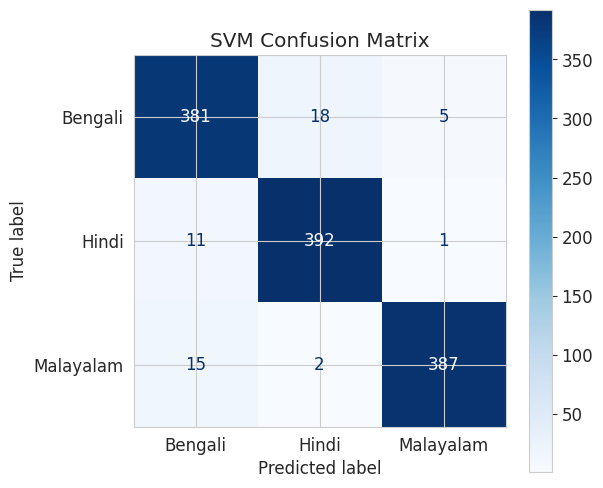


 Random Forest Accuracy: 97.52%

Sample Predictions for Random Forest:

Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali


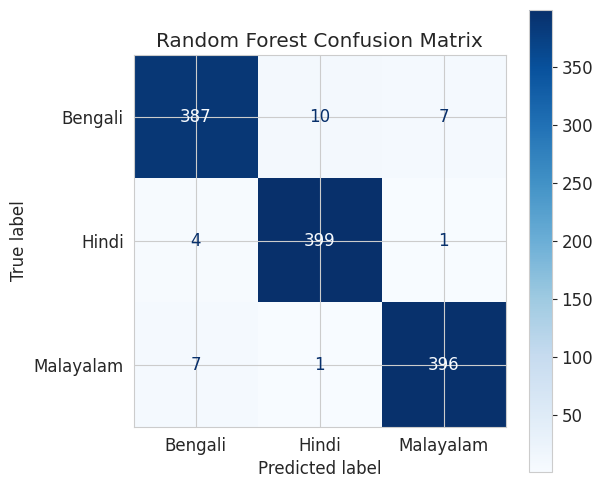

In [59]:
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n SVM Accuracy: {acc_svm*100:.2f}%")

show_sample_predictions(y_test, y_pred_svm, label_encoder, "SVM")
plot_conf_matrix(y_test, y_pred_svm, label_encoder.classes_, "SVM Confusion Matrix", "svm_confusion_matrix.png")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n Random Forest Accuracy: {acc_rf*100:.2f}%")


show_sample_predictions(y_test, y_pred_rf, label_encoder, "Random Forest")
plot_conf_matrix(y_test, y_pred_rf, label_encoder.classes_, "Random Forest Confusion Matrix", "rf_confusion_matrix.png")


Sample Predictions for Simple Neural Network:

Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali
Actual: Malayalam --- Predicted: Malayalam
Actual: Bengali --- Predicted: Bengali
Actual: Hindi --- Predicted: Hindi
Actual: Bengali --- Predicted: Bengali


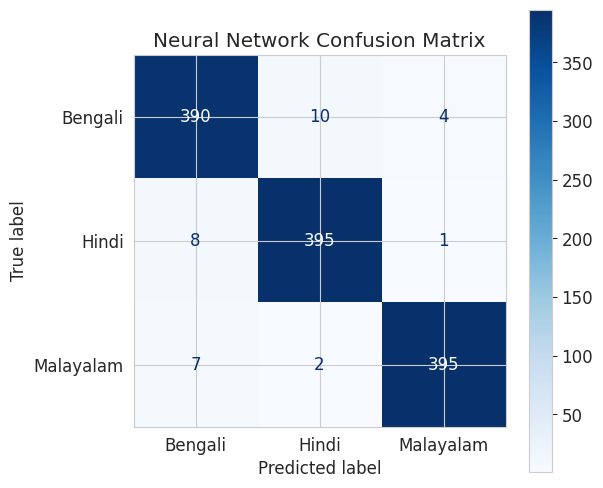


 All confusion matrices saved to /content/drive/MyDrive/SU_2/results


In [60]:
show_sample_predictions(all_labels_nn, all_preds_nn, label_encoder, "Simple Neural Network")
plot_conf_matrix(all_labels_nn, all_preds_nn, label_encoder.classes_, "Neural Network Confusion Matrix", "nn_confusion_matrix.png")

print(f"\n All confusion matrices saved to {save_path}")